# Week 7 - Model Optimisation and Engineering Trade-offs

**Author**: Sariana Ramoutar

---

# SECTION 1: Baseline Model of an Explainable AI Assistant to Support Emergency Department Triage (Week 6)

This notebook develops baseline machine learning models to predict Emergency Severity Index (ESI) levels using emergency department triage data.

The workflow follows good machine learning practice by:
- loading and preparing the data
- preventing data leakage
- splitting the data into training and testing sets
- training baseline classifiers
- evaluating model performance
- comparing against a random baseline
- exploring model interpretability using Explainable AI principles.

## 1. Setting Up the Workspace

In [1]:
# Import necessary libraries for data handling, plotting, and file operations.
import os # For interacting with the operating system, e.g., creating directories.
import pandas as pd # For data manipulation and analysis using DataFrames.
import numpy as np # For numerical operations.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualisations.
import seaborn as sns # For making attractive and informative statistical graphics.

In [2]:
# Set pandas display options to ensure that DataFrames are fully visible and easy to read.
# 'display.max_columns = None' ensures all columns are shown.
# 'display.max_rows = 100' ensures up to 100 rows are shown before truncation.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Define the folder names for storing figures (plots) and trained models.
FIGS_FOLDER = 'figs'
MODELS_FOLDER = 'models'

# Create the 'figs' folder if it does not already exist.
# This ensures a place to save any visualisations generated.
if not os.path.exists(FIGS_FOLDER):
    os.makedirs(FIGS_FOLDER)
    print(f"Created folder: {FIGS_FOLDER}/")

# Create the 'models' folder if it does not already exist.
# This ensures a place to save any machine learning models trained later.
if not os.path.exists(MODELS_FOLDER):
    os.makedirs(MODELS_FOLDER)
    print(f"Created folder: {MODELS_FOLDER}/")

Created folder: figs/
Created folder: models/


## 2. Loading the Patient Data

In [4]:
# Mount Google Drive to allow this Colab notebook to access files stored in your Drive.
# A pop-up will appear asking for authentication to connect to your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define the file path for the cleaned CSV dataset in Google Drive.
FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv'

# Load the cleaned CSV file into a pandas DataFrame.
# This dataset is expected to be pre-processed and ready for modelling.
triage_df = pd.read_csv(FILE_PATH)

# Print a confirmation message to indicate successful data loading.
print(f"Successfully loaded data from: {FILE_PATH}")

Successfully loaded data from: /content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv


In [6]:
# Print the number of rows (observations) and columns (features) in the loaded DataFrame.
# This gives a quick overview of the dataset's size.
print(f"The dataset contains {triage_df.shape[0]} rows and {triage_df.shape[1]} columns.")

# Display the first 5 rows of the DataFrame.
# This helps in quickly inspecting the data structure, column names, and initial values.
print("\nFirst 5 rows of the dataset:")
display(triage_df.head())

The dataset contains 55121 rows and 226 columns.

First 5 rows of the dataset:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [7]:
# Check for any missing values across all columns in the DataFrame.
# '.isnull()' identifies missing values, and '.sum()' counts them per column.
missing_values_summary = triage_df.isnull().sum()

# Filter the summary to only show columns that have at least one missing value.
# This provides a concise report of any data completeness issues.
missing_values_summary = missing_values_summary[missing_values_summary > 0]

# Display the summary of missing values.
if not missing_values_summary.empty:
    print("\nSummary of missing values per column:")
    display(missing_values_summary)
else:
    print("\nNo missing values found in the dataset, as expected from a 'cleaned' dataset.")


No missing values found in the dataset, as expected from a 'cleaned' dataset.


/tmp/ipykernel_488/1991818670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')


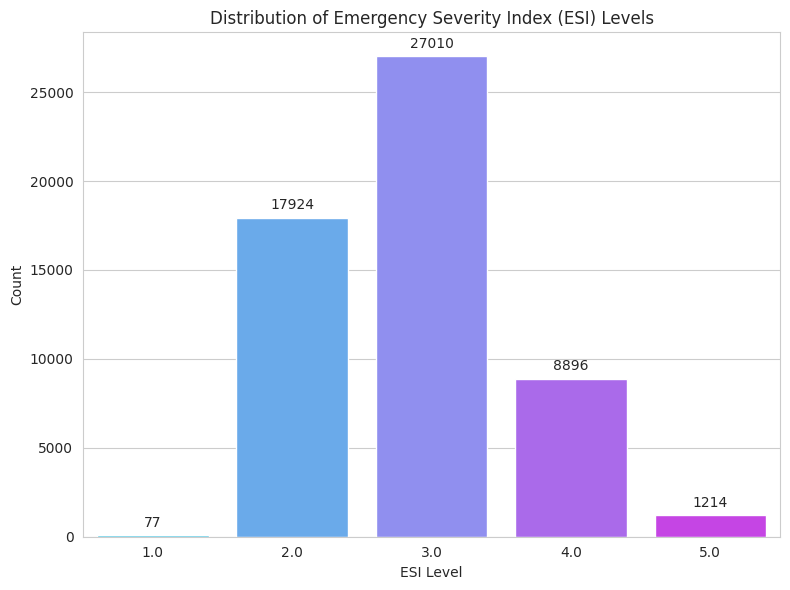

In [8]:
# Visualise the distribution of the target variable, 'esi' (Emergency Severity Index).
# This plot helps to understand the frequency of each ESI level in the dataset.

# Set the aesthetic style of the plots for better readability.
sns.set_style("whitegrid")

# Create a figure and an axes object for the plot with a specified size.
plt.figure(figsize=(8, 6))

# Use seaborn's countplot to show the distribution of 'esi' levels.
# 'order' ensures the ESI levels are plotted in numerical order on the x-axis.
sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')

# Add a descriptive title to the plot.
plt.title('Distribution of Emergency Severity Index (ESI) Levels')

# Label the x-axis and y-axis clearly.
plt.xlabel('ESI Level')
plt.ylabel('Count')

# Display the exact count of each ESI level on top of the bars for quick reference.
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

# Adjust layout to prevent labels from being cut off and then display the plot.
plt.tight_layout()
plt.show()

### Understanding the Target Variable Distribution

The Emergency Severity Index (ESI) is an imbalanced target variable. Most patients fall into the middle triage categories, while the most and least urgent cases occur much less frequently.

> **Why this matters**
>
> Rare classes are often the most difficult to predict, but they can also have the greatest clinical impact. Model performance should therefore be assessed across all ESI levels rather than overall accuracy alone.

| Observation | Impact |
|:--|:--|
| ESI classes are unevenly distributed | Creates a class imbalance problem |
| ESI 1 and ESI 5 are uncommon | Rare cases may be harder for the model to identify |
| Middle categories dominate | Models may become biased towards common classes |

In [9]:
# Inspect all column names in the dataset to verify exact vital sign naming.
# Since our feature selection returned 0 vital sign columns, this list will
# allow us to find the exact strings used for temperature, heart rate, etc.
print("======= Column Name Inspection =======")
print(f"Listing all {triage_df.shape[1]} columns in alphabetical order:\n")

# Loop through and print each column name in a clean, scrollable list
for col in sorted(triage_df.columns):
    print(col)

print("======================================")

======= Column Name Inspection =======
Listing all 226 columns in alphabetical order:

Unnamed: 0
age
arrivalday
arrivalhour_bin
arrivalmode
arrivalmonth
cc_abdominalcramping
cc_abdominaldistention
cc_abdominalpain
cc_abdominalpainpregnant
cc_abnormallab
cc_abscess
cc_addictionproblem
cc_agitation
cc_alcoholintoxication
cc_alcoholproblem
cc_allergicreaction
cc_alteredmentalstatus
cc_animalbite
cc_ankleinjury
cc_anklepain
cc_anxiety
cc_arminjury
cc_armpain
cc_armswelling
cc_assaultvictim
cc_asthma
cc_backpain
cc_bleeding/bruising
cc_blurredvision
cc_bodyfluidexposure
cc_breastpain
cc_breathingdifficulty
cc_breathingproblem
cc_burn
cc_cardiacarrest
cc_cellulitis
cc_chestpain
cc_chesttightness
cc_chills
cc_coldlikesymptoms
cc_confusion
cc_conjunctivitis
cc_constipation
cc_cough
cc_cyst
cc_decreasedbloodsugar-symptomatic
cc_dehydration
cc_dentalpain
cc_depression
cc_detoxevaluation
cc_diarrhea
cc_dizziness
cc_drug/alcoholassessment
cc_drugproblem
cc_dyspnea
cc_dysuria
cc_earpain
cc_earprob

## 3. Selecting Features for Clinical Prediction

### Understanding the Target Variable

The target variable is the Emergency Severity Index (`esi`), a five-level triage system used to prioritise patients in the emergency department according to clinical urgency and expected resource requirements.

| ESI Level | Meaning |
|:--|:--|
| ESI 1 | Immediate, life-threatening condition |
| ESI 2 | High-risk or time-critical condition |
| ESI 3 | Stable but requires multiple resources |
| ESI 4 | Less urgent, few resources required |
| ESI 5 | Least urgent, minimal resources required |

The objective is to predict the correct ESI level using only information available during the initial triage assessment.

In [10]:
# Define the target variable's column name.
TARGET = 'esi'

# Define lists of column names that fall into different categories.
# These lists are based on common conventions in healthcare datasets like CariSurg tutorials.

# Demographics: Patient-specific information that might not be used as features in some models
# due to fairness considerations or clinical relevance for prediction.
DEMOGRAPHICS = [
    'age',
    'gender',
    'ethnicity',
    'race',
    'insurance_type'
]

# Administrative variables: Identifiers or system-generated codes not directly related to clinical state.
# 'Unnamed: 0' is often an artefact from CSV saving and should generally be excluded.
ADMIN = [
    'Unnamed: 0',
    'dep_name',
    'patient_id',
    'encounter_id',
    'visit_id',
    'disposition_id'
]

# Leakage variables: Information that would not be available at the time of triage prediction,
# or that directly or indirectly reveals the target variable. Using these would make the model
# seem artificially accurate.
LEAKAGE = [
    'n_edvisits', # Number of past ED visits, could be proxy for severity over time
    'n_admissions', # Number of past admissions, similar to n_edvisits
    'admitted_to_hospital', # Outcome post-triage, direct leakage
    'admission_type', # Type of admission, often determined post-triage
    'admission_source', # Source of admission, often determined post-triage
    'discharge_disposition', # Outcome after admission, direct leakage
    'discharge_destination', # Destination after discharge, direct leakage
    'length_of_stay', # Duration of hospital stay, direct leakage
    'admission_to_icu_flag', # Indicates ICU admission, direct leakage
    'icu_stay_days', # Duration of ICU stay, direct leakage
    'mortality_flag', # Indicates mortality, direct leakage
    'disposition_dt', # Date of disposition, indicates post-triage event
    'discharge_dt' # Date of discharge, indicates post-triage event
]

# Triage vital signs: Core physiological measurements taken during triage.
# These are crucial clinical features.
VITAL_SIGNS = [
    'triage_vital_dbp',
    'triage_vital_hr',
    'triage_vital_o2',
    'triage_vital_rr',
    'triage_vital_sbp',
    'triage_vital_temp',
    'triage_glucose'
]

# Combine all exclusion lists into one for easier filtering.
EXCLUDE_COLS = list(set(DEMOGRAPHICS + ADMIN + LEAKAGE + [TARGET]))

# Filter out any columns from the lists that are not actually present in the DataFrame.
# This prevents errors if the dataset does not contain all theoretical columns.
DEMOGRAPHICS = [col for col in DEMOGRAPHICS if col in triage_df.columns]
ADMIN = [col for col in ADMIN if col in triage_df.columns]
LEAKAGE = [col for col in LEAKAGE if col in triage_df.columns]
VITAL_SIGNS = [col for col in VITAL_SIGNS if col in triage_df.columns]
EXCLUDE_COLS = [col for col in EXCLUDE_COLS if col in triage_df.columns]

print(f"Target variable defined: {TARGET}")
print(f"Number of identified demographic columns: {len(DEMOGRAPHICS)}")
print(f"Number of identified administrative columns: {len(ADMIN)}")
print(f"Number of identified leakage columns: {len(LEAKAGE)}")
print(f"Number of identified vital sign columns: {len(VITAL_SIGNS)}")

Target variable defined: esi
Number of identified demographic columns: 4
Number of identified administrative columns: 2
Number of identified leakage columns: 0
Number of identified vital sign columns: 7


### The Importance of Avoiding Data Leakage

Data leakage occurs when a model is trained using information that would not be available when a prediction is actually made.

For emergency department triage, examples include hospital admission status, length of stay or the final diagnosis. These outcomes are only known after the patient has been assessed.

> **Key principle**
>
> Only information available during the initial triage assessment should be used to predict the ESI level.

| Suitable Features | Leakage Features |
|:--|:--|
| Vital signs | Admission status |
| Chief complaints | Length of stay |
| Demographics | Final diagnosis |

Removing leakage variables produces a model that reflects real clinical decision-making rather than artificially inflated performance.

In [11]:
# Create a working copy of the DataFrame to perform feature selection.
df_prepared = triage_df.copy()

# --- 1. Remove rows where the target variable is missing ---
# Although the initial check showed no missing values, this is a good practice step.
# It ensures that our model training will not be affected by undefined target outcomes.
original_rows = df_prepared.shape[0]
df_prepared.dropna(subset=[TARGET], inplace=True)
rows_after_target_nan_removal = df_prepared.shape[0]

if original_rows - rows_after_target_nan_removal > 0:
    print(f"Removed {original_rows - rows_after_target_nan_removal} rows due to missing target variable '{TARGET}'.")
else:
    print(f"No rows removed as target variable '{TARGET}' had no missing values.")


# --- 2. Select clinically available features ---

# Identify all chief complaint (cc_) columns that are numerical.
# These columns typically represent the presence or absence of a chief complaint.
cc_cols = [col for col in df_prepared.columns if col.startswith('cc_') and pd.api.types.is_numeric_dtype(df_prepared[col])]

# Combine vital signs and chief complaints to form the initial set of selected features.
selected_features = list(set(VITAL_SIGNS + cc_cols))

# Filter out any features that are in our exclusion list.
# This ensures no demographic, administrative, or leakage variables are included.
final_features = [col for col in selected_features if col not in EXCLUDE_COLS]

# Ensure the target variable is not accidentally in the final features list.
if TARGET in final_features:
    final_features.remove(TARGET)

# --- 3. Create feature matrix (X) and target vector (y) ---

# X will contain all the selected features that the model will use for prediction.
X = df_prepared[final_features]

# y will contain the target variable, which is what the model will try to predict.
y = df_prepared[TARGET]

print(f"\nTotal columns in original DataFrame: {triage_df.shape[1]}")
print(f"Number of initial chief complaint (cc_) variables detected: {len(cc_cols)}")
print(f"Number of core vital sign variables included: {len(VITAL_SIGNS)}")
print(f"Number of final selected features for X: {X.shape[1]}")
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

No rows removed as target variable 'esi' had no missing values.

Total columns in original DataFrame: 226
Number of initial chief complaint (cc_) variables detected: 200
Number of core vital sign variables included: 7
Number of final selected features for X: 207
Shape of X (features): (55121, 207)
Shape of y (target): (55121,)


In [12]:
# --- Fill missing feature values with the median ---
# For robust models, it's good practice to handle missing values in features.
# Using the median is a common strategy for numerical data as it is less sensitive
# to outliers than the mean.

# Calculate the median for each feature column in X.
# We store these medians so they can be used consistently for any future unseen data.
feature_medians = X.median()

# Although this dataset contained no missing feature values, the median-imputation code was retained as good
# machine learning practice and ensures the workflow remains robust if future datasets contain missing observations.

# Fill any missing (NaN) values in X using the calculated median for each respective column.
X_filled = X.fillna(feature_medians)

# Verify that there are no remaining missing values in the feature set.
missing_values_after_fill = X_filled.isnull().sum().sum()

print(f"Missing values in features before filling: {X.isnull().sum().sum()}")
print(f"Missing values in features after filling with median: {missing_values_after_fill}")

Missing values in features before filling: 0
Missing values in features after filling with median: 0


In [13]:
# --- Print a neat summary of the prepared dataset ---
patients_count = X_filled.shape[0]
features_count = X_filled.shape[1]
remaining_missing = X_filled.isnull().sum().sum()

print("\n==================================================")
print("             Dataset Preparation Summary")
print("==================================================")
print(f"Number of patients (rows) in X: {patients_count}")
print(f"Number of selected features (columns) in X: {features_count}")
print(f"Target variable: {TARGET}")
print(f"Remaining missing values in X: {remaining_missing}") # Should be 0
print("==================================================")


             Dataset Preparation Summary
Number of patients (rows) in X: 55121
Number of selected features (columns) in X: 207
Target variable: esi
Remaining missing values in X: 0


In [14]:
# --- Produce a small table listing the core triage vital signs included ---
# This table clearly presents the vital sign features that will be used by the model.

print("\nCore Triage Vital Signs Included:")
vital_signs_df = pd.DataFrame(VITAL_SIGNS, columns=['Vital Sign Feature'])
display(vital_signs_df)


Core Triage Vital Signs Included:


,Vital Sign Feature
0,triage_vital_dbp
1,triage_vital_hr
2,triage_vital_o2
3,triage_vital_rr
4,triage_vital_sbp
5,triage_vital_temp
6,triage_glucose


In [15]:
# --- Produce a second table showing the number of chief complaint variables ---
# This table summarises how many chief complaint indicators are part of the feature set.

# Re-detect cc_cols from X_filled columns to be accurate after feature selection
final_cc_cols = [col for col in X_filled.columns if col.startswith('cc_')]

print("\nSummary of Chief Complaint Variables:")
cc_summary_df = pd.DataFrame({'Category': ['Number of Chief Complaint Variables'], 'Count': [len(final_cc_cols)]})
display(cc_summary_df)


Summary of Chief Complaint Variables:


,Category,Count
0,Number of Chief Complaint Variables,200


/tmp/ipykernel_488/1541456572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')


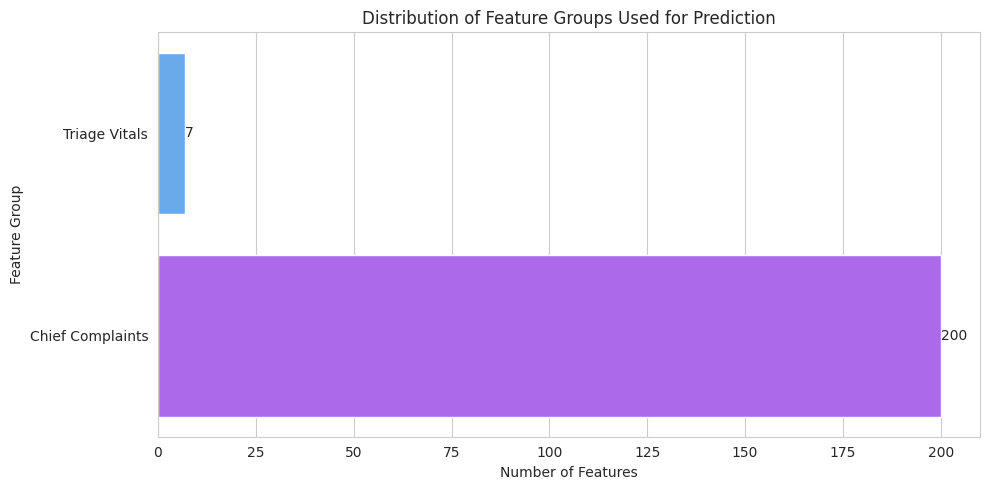

In [16]:
# --- Create a simple horizontal bar chart showing feature group counts ---
# This visualisation helps to quickly understand the composition of the feature set.

# Categorise features for plotting
included_vital_signs = [col for col in X_filled.columns if col in VITAL_SIGNS]
included_chief_complaints = [col for col in X_filled.columns if col.startswith('cc_')]

feature_groups_data = {
    'Feature Group': ['Triage Vitals', 'Chief Complaints'],
    'Count': [len(included_vital_signs), len(included_chief_complaints)]
}
feature_groups_df = pd.DataFrame(feature_groups_data)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')
plt.title('Distribution of Feature Groups Used for Prediction')
plt.xlabel('Number of Features')
plt.ylabel('Feature Group')

# Add counts on the bars
for index, value in enumerate(feature_groups_df['Count']):
    plt.text(value, index, str(value), va='center') # va='center' for better vertical alignment

plt.tight_layout()
plt.show()

In [17]:
print("DATA PREPARATION SUMMARY")
print(f"Patients included: {X_filled.shape[0]}")
print(f"Features selected: {X_filled.shape[1]}")
print("Missing values: 0")

DATA PREPARATION SUMMARY
Patients included: 55121
Features selected: 207
Missing values: 0


```
==================================================
✓ DATA PREPARATION COMPLETE

Patients included: 55121
Features selected: 207
Missing values: 0
Ready for train/test split.
==================================================
```

## 4. Preparing the Data for Machine Learning

### Part A – Why Split the Data

Before model training, the dataset is divided into separate training and testing sets.

– The training set is used to learn relationships between the features and the target.

– The testing set remains unseen until evaluation, providing an unbiased measure of performance.

– Stratification preserves the original distribution of ESI levels in both datasets.

– A fixed random seed (`random_state=42`) ensures the split can be reproduced.

> **Outcome**
>
> A fair evaluation that reflects how the model is expected to perform on new patients.

### Part B – Train/test split

In [18]:
# Import the required utility from scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
# We use 'stratify=y' to ensure the ESI class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Print the resulting patient counts for verification
print(f"Number of training patients: {X_train.shape[0]}")
print(f"Number of testing patients:  {X_test.shape[0]}")

Number of training patients: 44096
Number of testing patients:  11025


### Part C – Visualise the split

/tmp/ipykernel_488/2185488707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='cool')
/tmp/ipykernel_488/2185488707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[1], palette='cool')
/tmp/ipykernel_488/2185488707.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=axes[2], palette='cool')


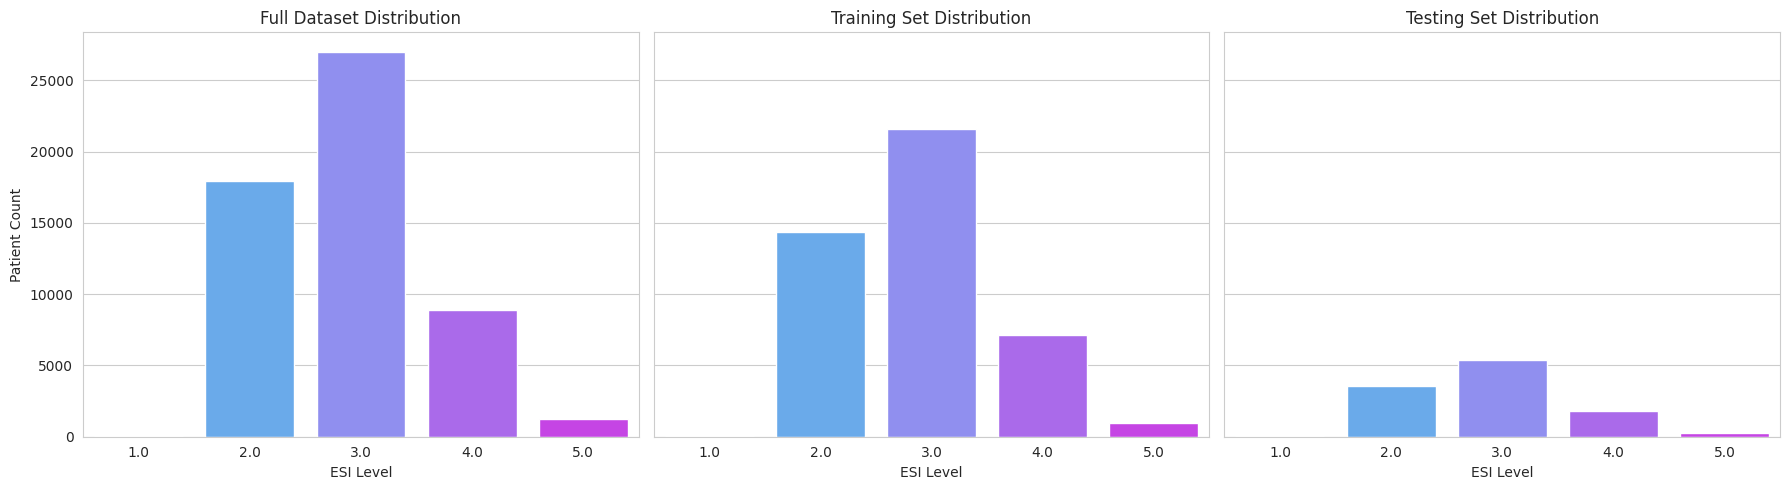

In [19]:
# Create a side-by-side comparison of the ESI distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot original full dataset
sns.countplot(x=y, ax=axes[0], palette='cool')
axes[0].set_title('Full Dataset Distribution')
axes[0].set_xlabel('ESI Level')
axes[0].set_ylabel('Patient Count')

# Plot training set
sns.countplot(x=y_train, ax=axes[1], palette='cool')
axes[1].set_title('Training Set Distribution')
axes[1].set_xlabel('ESI Level')

# Plot testing set
sns.countplot(x=y_test, ax=axes[2], palette='cool')
axes[2].set_title('Testing Set Distribution')
axes[2].set_xlabel('ESI Level')

plt.tight_layout()
plt.show()

The charts confirm that stratification preserved the original class distribution across both datasets, supporting a fair comparison during model evaluation.

### Part D – Feature Scaling

Some machine learning algorithms are sensitive to the scale of the input data, while others are not.

| Model | Scaling Required? | Reason |
|:--|:--:|:--|
| Logistic Regression | ✓ Yes | Performs best when features are on similar scales |
| Decision Tree | ✗ No | Uses threshold-based splits and is unaffected by feature magnitude |

Only the Logistic Regression pipeline applies feature scaling. The Decision Tree is trained using the original feature values.

In [20]:
# Import the standard scaling tool
from sklearn.preprocessing import StandardScaler

# Initialise the scaler
scaler = StandardScaler()

# We 'fit' the scaler ONLY on the training data to calculate means and standard deviations.
# This prevents information from the test set 'leaking' into our training process.
scaler.fit(X_train)

# Transform both training and testing sets using the parameters derived from the training set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Part E – Final summary

In [21]:
# Final status report for Section 3
print("==================================================")
print("\u2713 DATA READY FOR MODELLING")
print(f"Training patients: {X_train.shape[0]}")
print(f"Testing patients:  {X_test.shape[0]}")
print(f"Features:          {X_train.shape[1]}")
print("Scaling completed for Logistic Regression.")
print("Decision Tree will use original values.")
print("==================================================")

✓ DATA READY FOR MODELLING
Training patients: 44096
Testing patients:  11025
Features:          207
Scaling completed for Logistic Regression.
Decision Tree will use original values.


## 5. Building Baseline Machine Learning Models

Three baseline models are trained to establish a performance benchmark before model optimisation. Each model represents a different approach to classification, allowing their strengths and limitations to be compared.

### Part A – Dummy Classifier

The Dummy Classifier does not learn from the data. Instead, it generates predictions using a simple strategy, providing a minimum performance benchmark.

> **Purpose**
>
> Any useful machine learning model should outperform this baseline.

In [22]:
from sklearn.dummy import DummyClassifier

# Initialise the Dummy Classifier using the 'stratified' strategy.
# This strategy makes random guesses that match the distribution of the training set.
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Train the model using the unscaled training data.
dummy_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Dummy Classifier trained successfully")
print(f"Strategy used:    {dummy_clf.strategy}")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")

✓ Dummy Classifier trained successfully
Strategy used:    stratified
Training samples: 44096
Features:         207


### Part B – Logistic Regression

Logistic Regression is a widely used classification algorithm and serves as a strong baseline for structured clinical data.

– Produces interpretable feature coefficients.

– Uses the scaled training data to ensure features contribute on comparable scales.

– Provides a useful balance between performance and explainability.

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialise Logistic Regression.
# 'multi_class="auto"' and 'max_iter=1000' ensure it handles our 5 ESI levels correctly.
log_reg = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42)

# Train the model using the SCALED training data.
log_reg.fit(X_train_scaled, y_train)

# Print a success checkpoint.
print("\u2713 Logistic Regression trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")
print("Scaled data used: Yes")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✓ Logistic Regression trained successfully
Training samples: 44096
Features:         207
Scaled data used: Yes


### Part C – Logistic Regression Visualisation

The coefficient plot highlights the features that have the greatest influence on the model's predictions.

> **Interpretation**
>
> Larger positive or negative coefficients indicate stronger contributions to the predicted ESI level.

/tmp/ipykernel_488/1225429309.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')


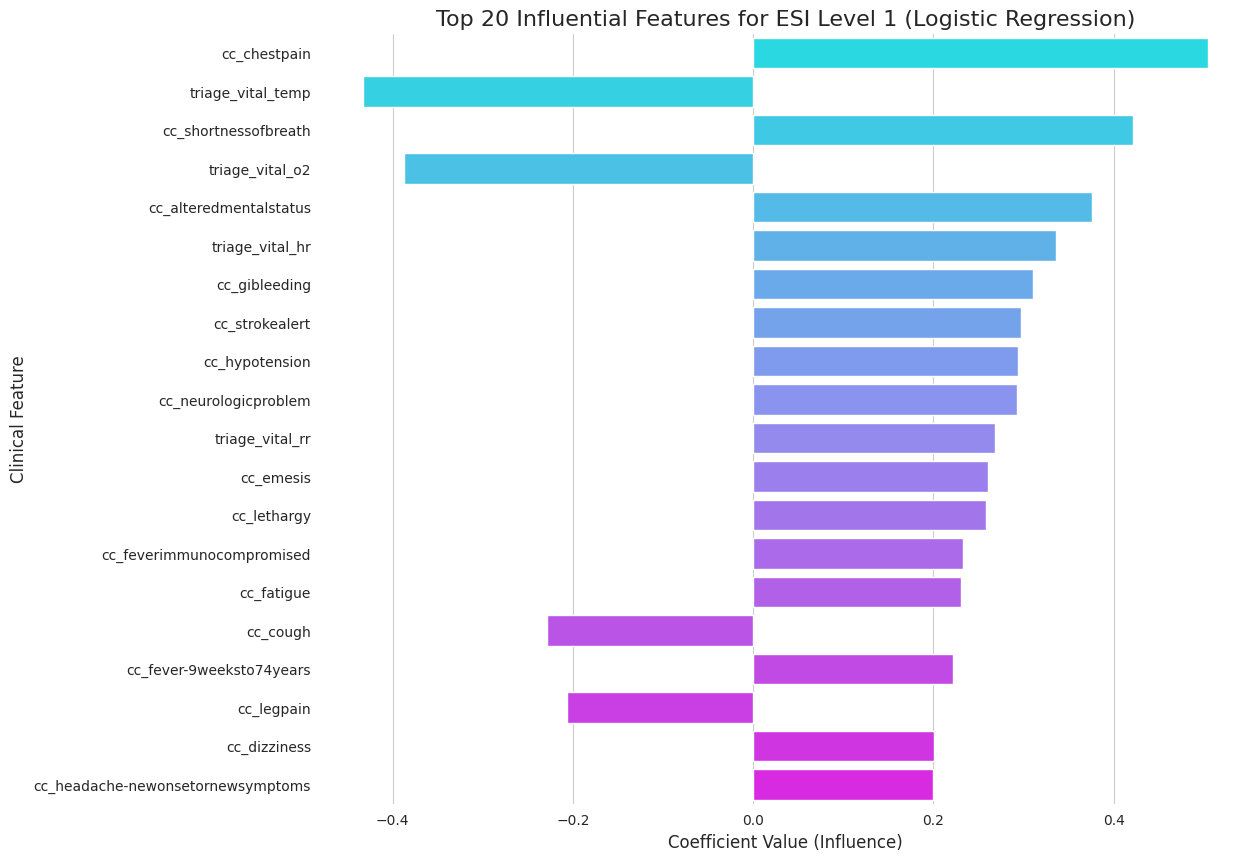

In [24]:
# Extract coefficients for ESI Level 1 (Index 0)
esi_1_coefs = log_reg.coef_[0]

# Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({'Feature': final_features, 'Coefficient': esi_1_coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Select the top 20 features by absolute influence
top_20_coefs = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Plotting the coefficients
plt.figure(figsize=(12, 10), dpi=100)
sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')

plt.title('Top 20 Influential Features for ESI Level 1 (Logistic Regression)', fontsize=16)
plt.xlabel('Coefficient Value (Influence)', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
sns.despine(left=True, bottom=True)

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'log_reg_top_coefs.png'), bbox_inches='tight')
plt.show()

### Part D – Decision Tree

A Decision Tree predicts outcomes by repeatedly splitting the data using simple decision rules.

| Feature | Benefit |
|:--|:--|
| Threshold-based decisions | Easy to understand |
| Tree structure | Naturally interpretable |
| `max_depth = 3` | Improves readability and reduces overfitting |

Only a shallow tree is used to maintain clinical interpretability.

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Initialise the Decision Tree.
# We use max_depth=3 to keep the model simple and explainable.
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model using the ORIGINAL (unscaled) training data.
dt_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Decision Tree trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Maximum depth:    {dt_clf.max_depth}")
print(f"Features:         {X_train.shape[1]}")

✓ Decision Tree trained successfully
Training samples: 44096
Maximum depth:    3
Features:         207


### Part E – Decision Tree Flowchart

The flowchart illustrates the sequence of decisions used by the model to assign an ESI level.

> **Reading the tree**
>
> Each branch represents a decision, while each leaf node shows the final prediction.

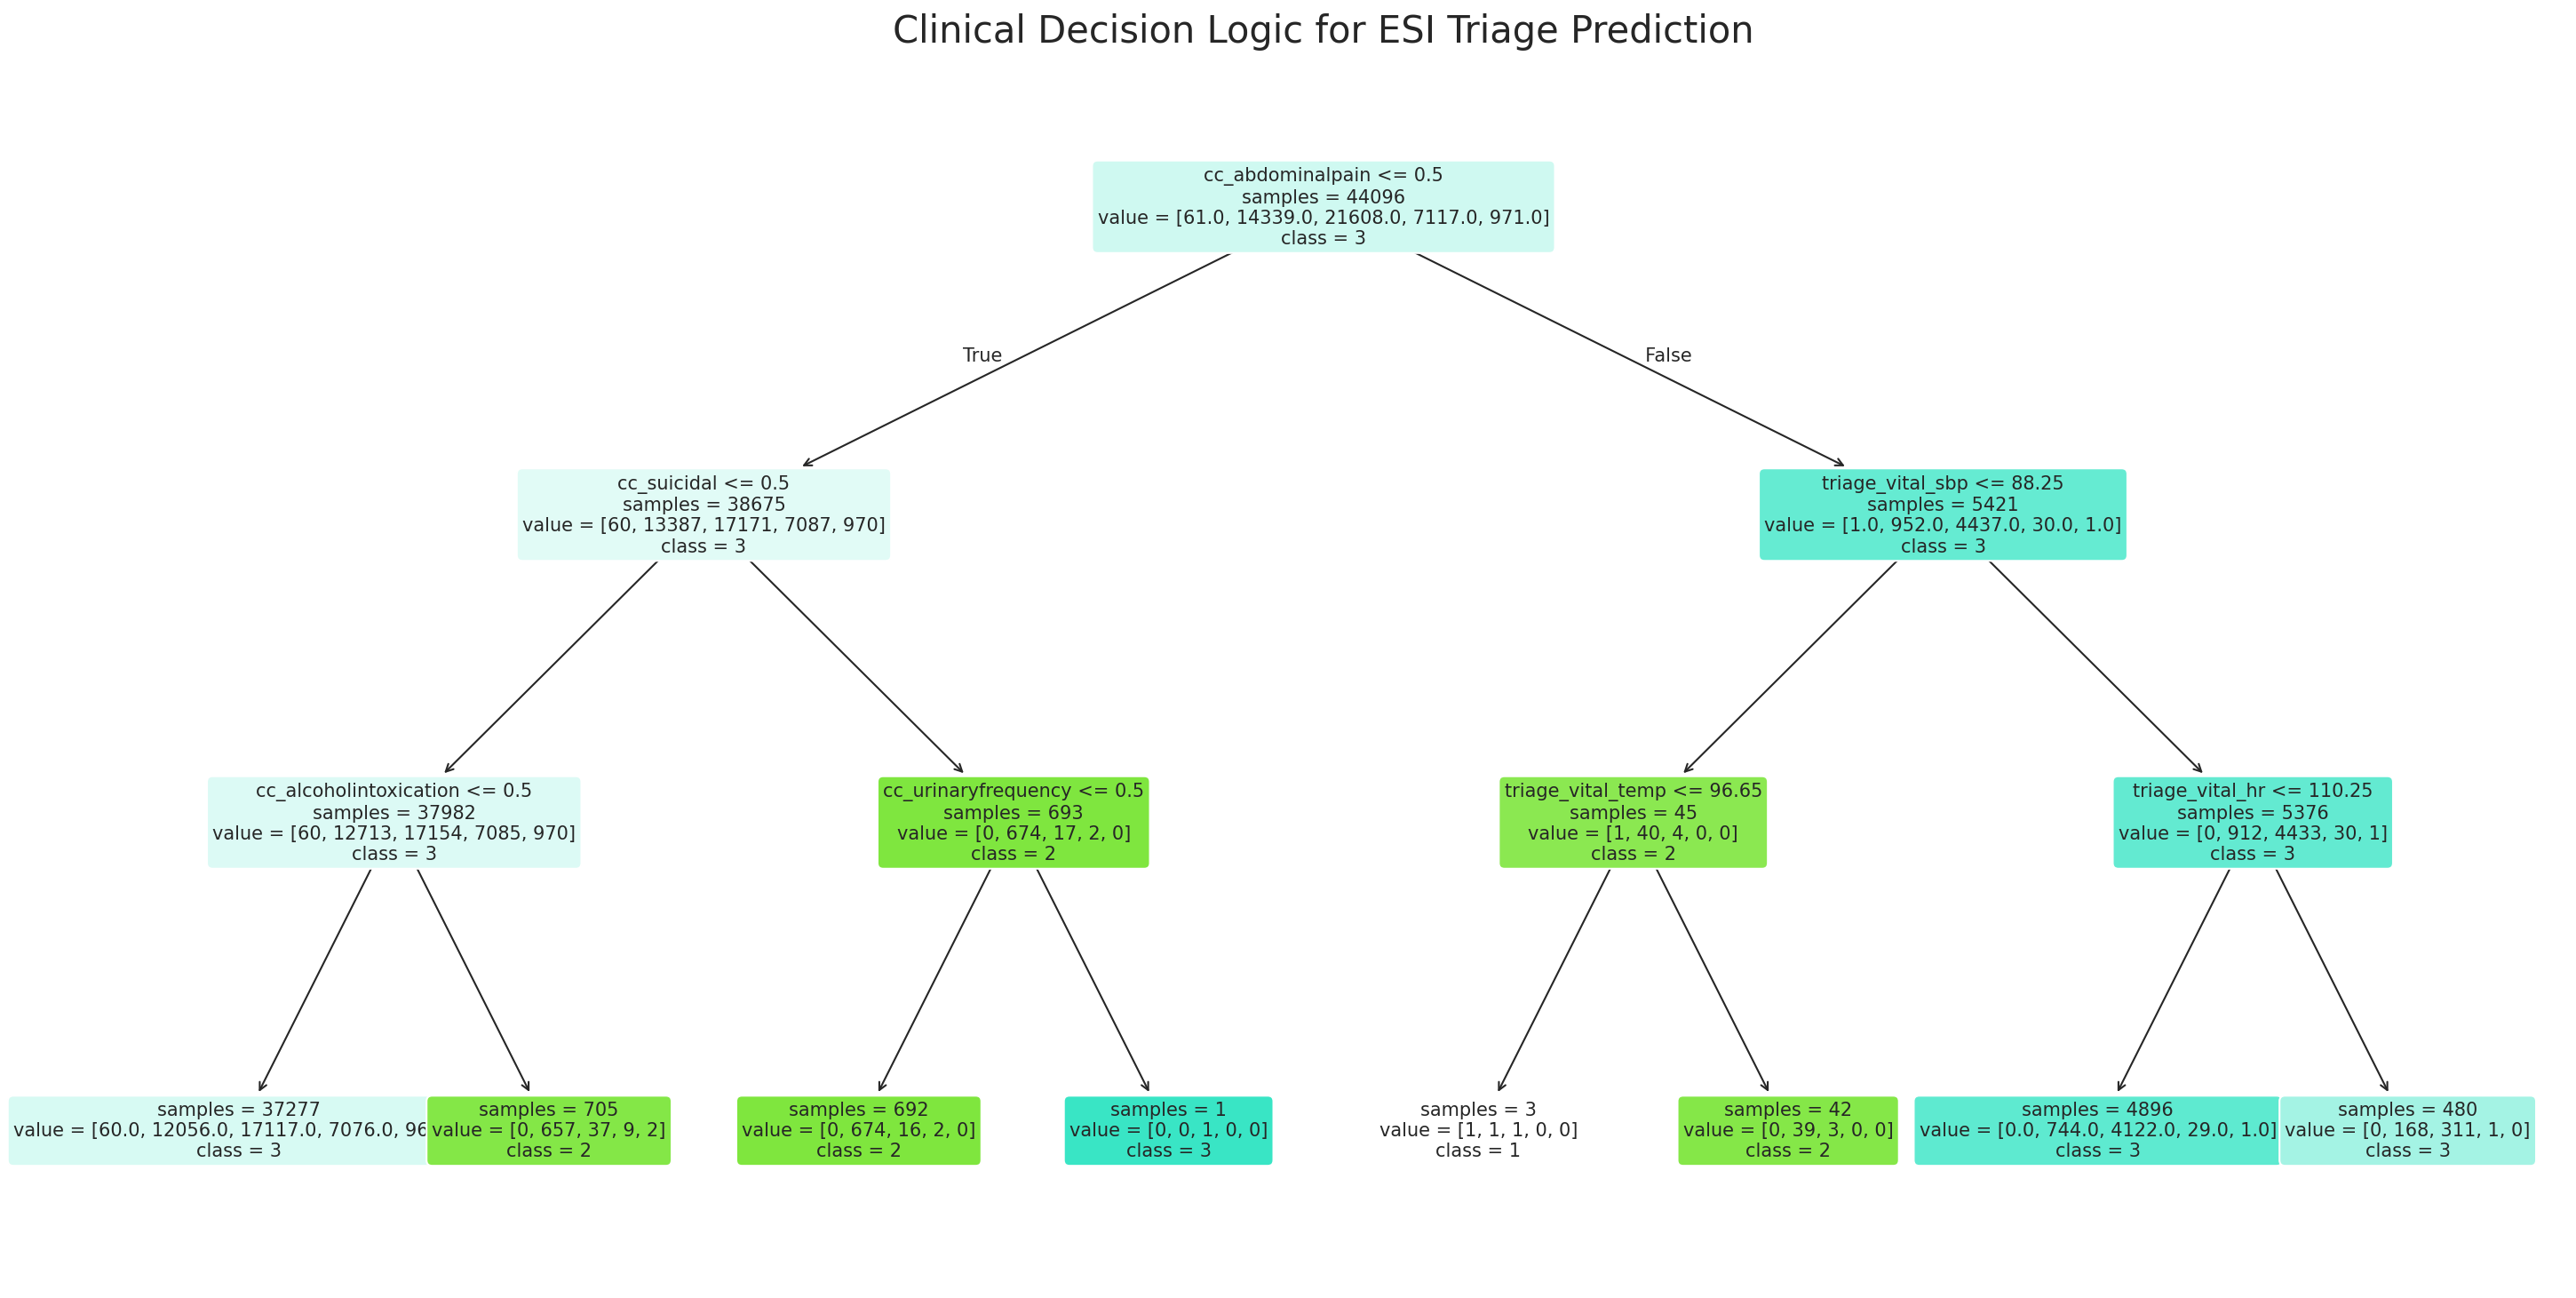

In [26]:
from sklearn.tree import plot_tree

# Set up a large figure for the flowchart
plt.figure(figsize=(24, 12), dpi=150)

# Define class names for display (ESI 1 to 5)
esi_classes = [str(int(c)) for c in sorted(y.unique())]

# Plot the tree
plot_tree(dt_clf,
          feature_names=final_features,
          class_names=esi_classes,
          filled=True,
          rounded=True,
          impurity=False,
          fontsize=10
          )

plt.title('Clinical Decision Logic for ESI Triage Prediction', fontsize=20)

# Save the flowchart
plt.savefig(os.path.join(FIGS_FOLDER, 'decision_tree_flowchart.png'), bbox_inches='tight')
plt.show()

In [27]:
# Final Checkpoint for Section 4
print("==================================================")
print("\n\u2713 ALL BASELINE MODELS TRAINED")
print("\n- Dummy Classifier")
print("- Logistic Regression")
print("- Decision Tree")
print("\nReady for evaluation.")
print("\n==================================================")


✓ ALL BASELINE MODELS TRAINED

- Dummy Classifier
- Logistic Regression
- Decision Tree

Ready for evaluation.



## 6. Evaluating Baseline Model Performance

The trained models are evaluated using the testing dataset to measure how well they generalise to unseen patient encounters.

### Part A – Generate Predictions

Each model predicts the ESI levels for the testing dataset.

– Logistic Regression uses the scaled features.

– The Dummy Classifier and Decision Tree use the original feature values.

In [28]:
# Generate predictions for each model using the test data
dummy_preds = dummy_clf.predict(X_test)
log_reg_preds = log_reg.predict(X_test_scaled)
dt_preds = dt_clf.predict(X_test)

print("\u2713 Test set predictions generated for all models.")

✓ Test set predictions generated for all models.


### Part B – Calculate Evaluation Metrics

Several evaluation metrics are used to assess model performance.

| Metric | Measures |
|:--|:--|
| Accuracy | Overall proportion of correct predictions |
| Precision | Correctness of positive predictions |
| Recall | Ability to identify the correct class |
| F1-score | Balance between precision and recall |

Together, these metrics provide a more complete assessment than accuracy alone.

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def get_metrics(y_true, y_pred, model_name):
    # Calculate accuracy
    acc = accuracy_score(y_true, y_pred)
    # Calculate precision, recall, and F1 for both macro and weighted averages
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

# Compile metrics for all models
metrics_list = [
    get_metrics(y_test, dummy_preds, 'Dummy Classifier'),
    get_metrics(y_test, log_reg_preds, 'Logistic Regression'),
    get_metrics(y_test, dt_preds, 'Decision Tree')
]

# Display full classification reports
print("--- Dummy Classifier Report ---")
print(classification_report(y_test, dummy_preds, zero_division=0))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, log_reg_preds, zero_division=0))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, dt_preds, zero_division=0))

--- Dummy Classifier Report ---
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        16
         2.0       0.33      0.33      0.33      3585
         3.0       0.49      0.50      0.49      5402
         4.0       0.15      0.15      0.15      1779
         5.0       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025


--- Logistic Regression Report ---
              precision    recall  f1-score   support

         1.0       0.29      0.12      0.17        16
         2.0       0.70      0.62      0.66      3585
         3.0       0.66      0.74      0.70      5402
         4.0       0.61      0.58      0.59      1779
         5.0       0.48      0.11      0.18       243

    accuracy                           0.66     11025
   macro avg       0.55      0.44      0.46     11025
weighted 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Part C – Create a Comparison Table

The evaluation metrics are combined into a single table to enable a direct comparison of model performance.

In [30]:
# Create a DataFrame to summarise results
comparison_df = pd.DataFrame(metrics_list)

# Round values to three decimal places for clarity
comparison_df = comparison_df.round(3)

print("Model Performance Comparison Table:")
display(comparison_df)

Model Performance Comparison Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Dummy Classifier,0.375,0.204,0.204,0.204,0.375
1,Logistic Regression,0.662,0.547,0.436,0.461,0.656
2,Decision Tree,0.518,0.290,0.218,0.168,0.383


### Part D – Visual Comparison

The charts provide a quick comparison of model performance across the different evaluation metrics, making overall trends easier to identify.

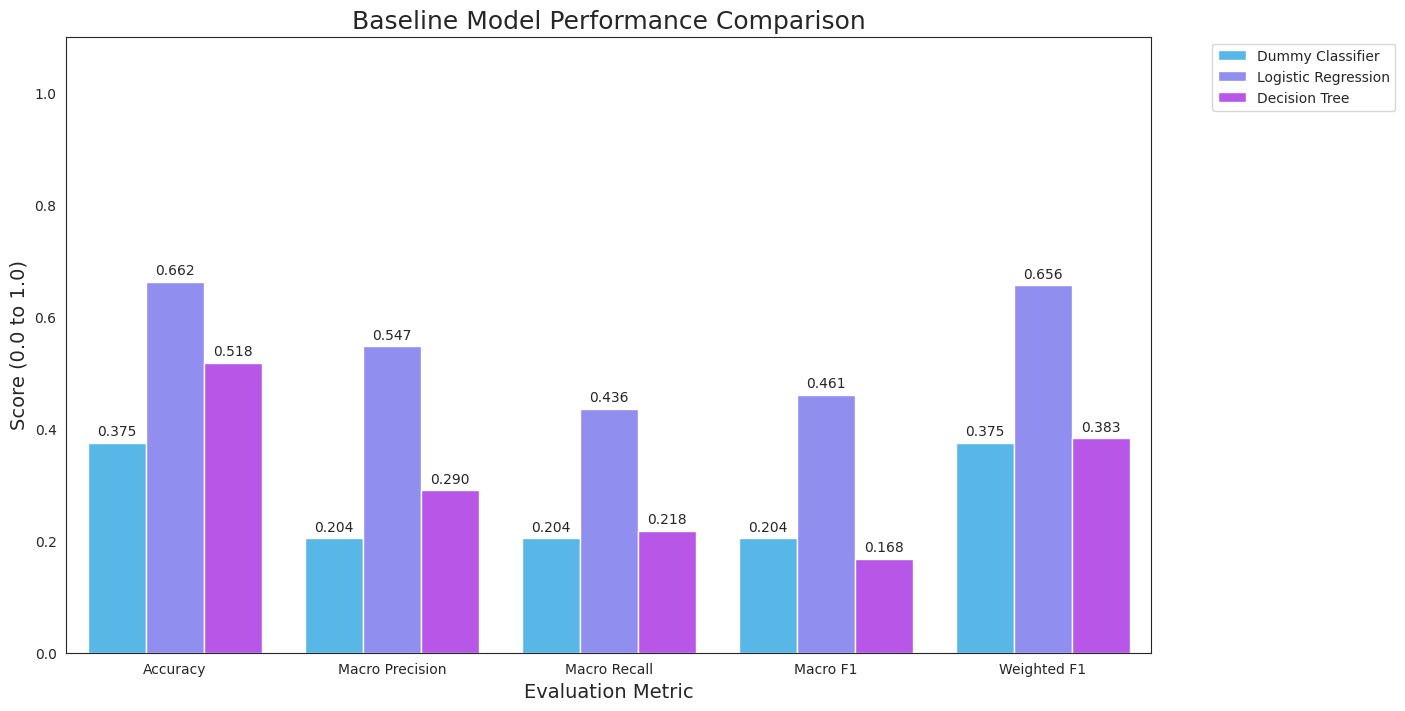

In [31]:
# Melt the DataFrame for easier plotting with seaborn
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("white")
bar_plot = sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df, palette='cool')

# Add labels to the bars
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.3f', padding=3)

plt.title('Baseline Model Performance Comparison', fontsize=18)
plt.ylim(0, 1.1) # Set Y-axis slightly higher than 1.0 for labels
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'model_metric_comparison.png'), bbox_inches='tight')
plt.show()

In [32]:
# Create a qualitative comparison table for the three models
model_summary_data = {
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree"],
    "Needs Scaling": ["No", "Yes", "No"],
    "Explainability": ["High (Random/Simple)", "High (Coefficients)", "Very High (Flowchart)"],
    "Clinical Strength": ["None (Baseline only)", "Strong (Risk Factor identification)", "Strong (Decision Logic support)"],
    "Clinical Use Case": ["Reference Point", "Statistical Benchmarking", "Triage Assistant Prototype"]
}

model_summary_df = pd.DataFrame(model_summary_data)

print("Qualitative Comparison of Baseline Models:")
display(model_summary_df)

Qualitative Comparison of Baseline Models:


,Model,Needs Scaling,Explainability,Clinical Strength,Clinical Use Case
0,Dummy Classifier,No,High (Random/Simple),None (Baseline only),Reference Point
1,Logistic Regression,Yes,High (Coefficients),Strong (Risk Factor identification),Statistical Benchmarking
2,Decision Tree,No,Very High (Flowchart),Strong (Decision Logic support),Triage Assistant Prototype


### Part E – Confusion Matrices

A confusion matrix compares the predicted and true ESI levels, making classification errors easy to identify.

> **Why it matters**
>
> Not all errors have the same clinical importance. Identifying which ESI levels are confused helps to evaluate patient safety.

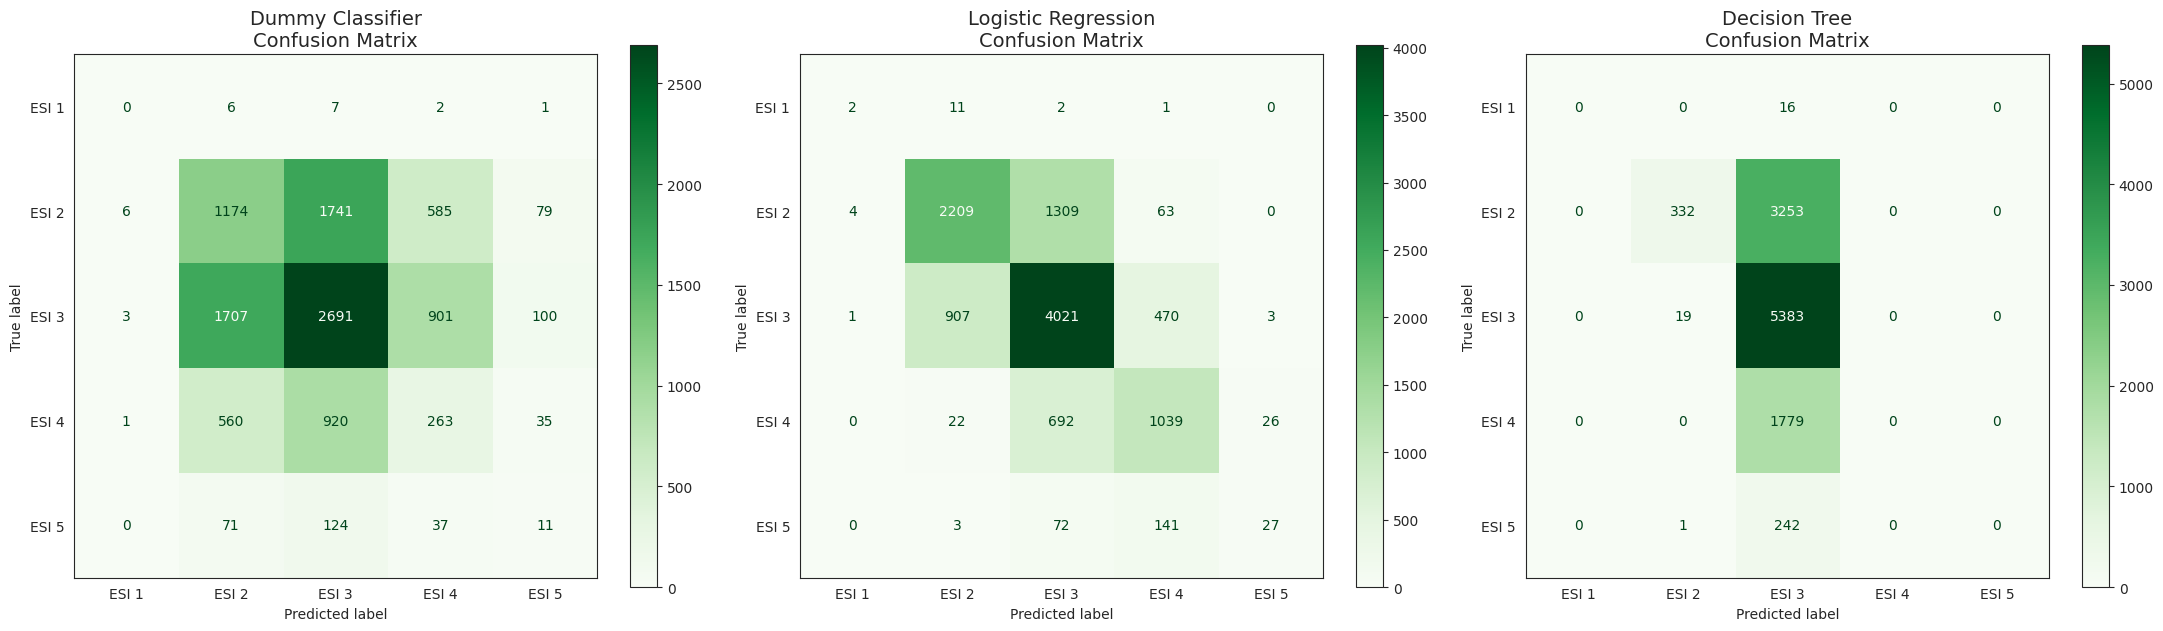

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up class labels
esi_labels = [f"ESI {int(c)}" for c in sorted(y.unique())]
models = [dummy_clf, log_reg, dt_clf]
model_names = ['Dummy Classifier', 'Logistic Regression', 'Decision Tree']
preds = [dummy_preds, log_reg_preds, dt_preds]

# Create a side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

for i, (pred, name) in enumerate(zip(preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=True)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'confusion_matrices_baseline.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical Interpretation

The evaluation highlights several clinically important findings.

– Confusion matrices reveal which ESI levels are most frequently misclassified.

– Overall accuracy should not be interpreted in isolation, particularly with an imbalanced dataset.

– Correct identification of high-acuity patients remains the most important consideration for safe triage.

> **Clinical perspective**
>
> A model that performs well across all ESI levels is more valuable than one that simply achieves high overall accuracy.

In [34]:
# Final status report for Section 5
print("==================================================")
print("\n\u2713 MODEL EVALUATION COMPLETE")
print("\nDummy Classifier evaluated")
print("Logistic Regression evaluated")
print("Decision Tree evaluated")
print("\nReady for detailed performance analysis.")
print("\n==================================================")


✓ MODEL EVALUATION COMPLETE

Dummy Classifier evaluated
Logistic Regression evaluated
Decision Tree evaluated

Ready for detailed performance analysis.



## 7. Interpreting the Results and Clinical Relevance

Good model performance alone is not enough for clinical use. The results also need to be understandable, trustworthy and clinically meaningful.

This section explains what the evaluation metrics show and how the baseline models support the development of an explainable triage assistant.

### Part A – Comparing the Evaluation Metrics

Different metrics highlight different aspects of model performance.

| Metric | Plain English |
|:--|:--|
| Accuracy | How often the prediction was correct overall |
| Precision | How often a predicted class was actually correct |
| Recall | How many of the true cases the model successfully found |
| F1-score | A balance between Precision and Recall |

> **Why use more than one metric?**
>
> Accuracy alone can be misleading in an imbalanced dataset. Looking at several metrics provides a more complete picture of model performance.

| Average | Gives more importance to... |
|:--|:--|
| Weighted F1 | Common ESI levels |
| Macro F1 | Every ESI level equally |

### Part B – Why Recall Matters

In emergency care, not every prediction error has the same consequence.

A patient with a lower-acuity condition may experience a longer wait if classified incorrectly. However, failing to identify a patient who requires urgent treatment can have much more serious consequences.

> **Clinical perspective**
>
> In many situations, it is safer for a model to recommend a higher priority than to overlook a patient who requires immediate attention.

### Part C – Logistic Regression Interpretation

Logistic Regression provides a transparent baseline because the importance of each feature can be examined directly.

– The coefficient plot highlights the variables that most influenced the predictions.

– Chief complaints and physiological measurements were among the strongest predictors.

– Performance was strongest overall, although some higher-acuity cases remained difficult to identify.

> **Why this matters**
>
> The model allows clinicians to understand which clinical features influenced each prediction, supporting explainable decision-making.

### Part D – Decision Tree Interpretation

The Decision Tree provides a visual representation of the prediction process.

– Each decision node applies a simple clinical rule.

– Following the branches shows how the final prediction was reached.

– Every prediction can be traced back through a sequence of understandable decisions.

> **Explainable AI**
>
> Unlike many complex models, a Decision Tree allows clinicians to see exactly how a prediction was produced.

### Part E – Failure Modes

No model performs perfectly. The confusion matrices help identify where prediction errors occur.

– Less common ESI levels were generally more difficult to classify.

– Some neighbouring ESI levels showed overlapping predictions, reflecting similar clinical presentations.

– These results highlight opportunities for improvement through feature engineering and model optimisation.

> **Key finding**
>
> Understanding where models make mistakes is just as important as measuring overall performance.

### Final Takeaway

The baseline models provide a useful foundation for further development.

| Model | Main strength |
|:--|:--|
| Logistic Regression | Strong baseline performance with interpretable feature importance |
| Decision Tree | Transparent decision-making process |

Together, these models demonstrate how predictive performance and interpretability can be balanced when developing an explainable clinical decision-support system.

## 8. Saving Outputs and Project Summary

The trained models, evaluation results and supporting outputs are saved for future analysis. This section also summarises the main outcomes of the notebook.

### Part A – Save Trained Models

Use the `joblib` library to save the models. This allows the models to be reloaded later (for example, in a real-time triage application) without needing to retrain them from scratch.

In [35]:
import joblib

# Define filenames for the models
dummy_path = os.path.join(MODELS_FOLDER, 'dummy_classifier_baseline.joblib')
log_reg_path = os.path.join(MODELS_FOLDER, 'logistic_regression_baseline.joblib')
dt_path = os.path.join(MODELS_FOLDER, 'decision_tree_baseline.joblib')

# Save each model using joblib
joblib.dump(dummy_clf, dummy_path)
print(f"\u2713 Saved Dummy Classifier to: {dummy_path}")

joblib.dump(log_reg, log_reg_path)
print(f"\u2713 Saved Logistic Regression to: {log_reg_path}")

joblib.dump(dt_clf, dt_path)
print(f"\u2713 Saved Decision Tree to: {dt_path}")

✓ Saved Dummy Classifier to: models/dummy_classifier_baseline.joblib
✓ Saved Logistic Regression to: models/logistic_regression_baseline.joblib
✓ Saved Decision Tree to: models/decision_tree_baseline.joblib


### Part B – Save the Comparison Table

Save the performance metrics as a CSV file. This is useful for including in formal reports or comparing against future models.

In [36]:
# Save the comparison DataFrame to the figs folder for reporting
csv_output_path = os.path.join(FIGS_FOLDER, 'model_comparison_results.csv')
comparison_df.to_csv(csv_output_path, index=False)

print(f"\u2713 Model comparison table saved to: {csv_output_path}")

✓ Model comparison table saved to: figs/model_comparison_results.csv


### Part C – Notebook Summary

This notebook established baseline models for predicting Emergency Severity Index (ESI) levels.

| Completed task | Outcome |
|:--|:--|
| Dataset preparation | Verified the cleaned dataset |
| Feature selection | Included 200 chief complaints and 7 triage vital signs |
| Train/test split | Created a stratified 80/20 split |
| Logistic Regression | Built an interpretable baseline model |
| Decision Tree | Developed an explainable decision model |
| Dummy Classifier | Established a minimum performance benchmark |
| Model evaluation | Compared Accuracy, Precision, Recall and F1-score |
| Confusion matrices | Identified common prediction errors |
| Clinical interpretation | Related model performance to emergency triage |

### Part E – Future Work

Possible next steps include:

– Evaluating additional machine learning models.

– Improving performance for under-represented ESI levels.

– Validating the models using data from other hospitals.

– Expanding explainable AI techniques to improve clinical transparency and trust.

In [37]:
# Final notebook checkpoint
print("==================================================")
print("\n\u2713 WEEK 6 BASELINE MODELLING COMPLETE")
print("\n- Dataset prepared")
print("- Three baseline models trained")
print("- Models evaluated")
print("- Clinical interpretation completed")
print("\n==================================================")


✓ WEEK 6 BASELINE MODELLING COMPLETE

- Dataset prepared
- Three baseline models trained
- Models evaluated
- Clinical interpretation completed



# SECTION 2: Model Optimisation and Engineering Trade-offs (Week 7)

## 9. Clinical Feature Engineering

### Part A – Introduction

The baseline models established a reference point for predicting Emergency Severity Index (ESI) levels. The next stage explores whether engineered clinical features can improve model performance while maintaining transparency.

Model selection in healthcare is rarely based on accuracy alone.

| Consideration | Why it matters |
|:--|:--|
| Predictive performance | Supports reliable clinical decisions |
| Interpretability | Helps clinicians understand predictions |
| Computational efficiency | Enables rapid decision-making |
| Deployment | Supports integration into clinical workflows |

The following sections investigate how feature engineering can strengthen model performance without compromising explainability.

### Part B – Why Feature Engineering Matters

Feature engineering creates new variables from existing clinical information to better represent a patient's condition.

Rather than analysing measurements individually, clinically meaningful combinations can provide additional insight.

> **Example**
>
> A patient's heart rate and blood pressure can be combined to calculate a shock index, which may provide a stronger indication of physiological instability than either measurement alone.

### Part C – Create Engineered Clinical Features

In [38]:
# This function adds clinically meaningful engineered features to a DataFrame.
# It operates on a copy of the input DataFrame to avoid modifying the original.
# Features are only created if all required source columns exist in the DataFrame.
def add_clinical_features(df):
    df_engineered = df.copy()
    new_features_created = {}

    # Bradycardia indicator: Heart rate below 60 bpm
    if 'triage_vital_hr' in df_engineered.columns:
        df_engineered['eng_bradycardia'] = (df_engineered['triage_vital_hr'] < 60).astype(int)
        new_features_created['eng_bradycardia'] = 'Identifies unusually slow heart rate.'

    # Hyperglycaemia indicator: Glucose above 180 mg/dL (common threshold)
    if 'triage_vital_glucose' in df_engineered.columns:
        df_engineered['eng_hyperglycemia'] = (df_engineered['triage_vital_glucose'] > 180).astype(int)
        new_features_created['eng_hyperglycemia'] = 'Indicates abnormally high blood sugar levels.'

    # Hypothermia indicator: Temperature below 35 °C
    if 'triage_vital_temp' in df_engineered.columns:
        df_engineered['eng_hypothermia'] = (df_engineered['triage_vital_temp'] < 35).astype(int)
        new_features_created['eng_hypothermia'] = 'Flags abnormally low body temperature.'

    # Respiratory distress indicator: Respiratory rate above 20 breaths/min
    if 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_respiratory_distress'] = (df_engineered['triage_vital_rr'] > 20).astype(int)
        new_features_created['eng_respiratory_distress'] = 'Identifies increased breathing effort or rate.'

    # Oxygen saturation to respiratory rate ratio
    if 'triage_vital_o2' in df_engineered.columns and 'triage_vital_rr' in df_engineered.columns:
        # Avoid division by zero by replacing 0 respiratory rate with a small number or NaN
        df_engineered['eng_o2_rr_ratio'] = df_engineered['triage_vital_o2'] / df_engineered['triage_vital_rr'].replace(0, np.nan)
        new_features_created['eng_o2_rr_ratio'] = 'Ratio indicating respiratory efficiency; lower values suggest poorer lung function.'

    return df_engineered, new_features_created

### Part D – Apply Feature Engineering

In [39]:
# Apply the feature engineering function to both the training and testing sets.
# This creates new feature-engineered DataFrames without modifying the originals (X_train, X_test).
X_train_fe, train_new_features = add_clinical_features(X_train)
X_test_fe, _ = add_clinical_features(X_test) # Don't need new features dict for test set

# Print a summary of the feature engineering process
original_num_features = X_train.shape[1]
engineered_num_features = X_train_fe.shape[1]
num_new_features = engineered_num_features - original_num_features

print(f"Original number of features: {original_num_features}")
print(f"Engineered number of features: {engineered_num_features}")
print(f"Number of new features added: {num_new_features}")

Original number of features: 207
Engineered number of features: 211
Number of new features added: 4


### Part E – Clinical Feature Summary

In [40]:
# Create a DataFrame to summarise the newly engineered features and their clinical purposes.
engineered_features_summary_df = pd.DataFrame.from_dict(
    train_new_features, orient='index', columns=['Clinical Purpose']
).reset_index()
engineered_features_summary_df.columns = ['Feature', 'Clinical Purpose']

print("Successfully created engineered features:")
display(engineered_features_summary_df)

Successfully created engineered features:


,Feature,Clinical Purpose
0,eng_bradycardia,Identifies unusually slow heart rate.
1,eng_hypothermia,Flags abnormally low body temperature.
2,eng_respiratory_distress,Identifies increased breathing effort or rate.
3,eng_o2_rr_ratio,Ratio indicating respiratory efficiency; lower...


### Part F – Visualisation

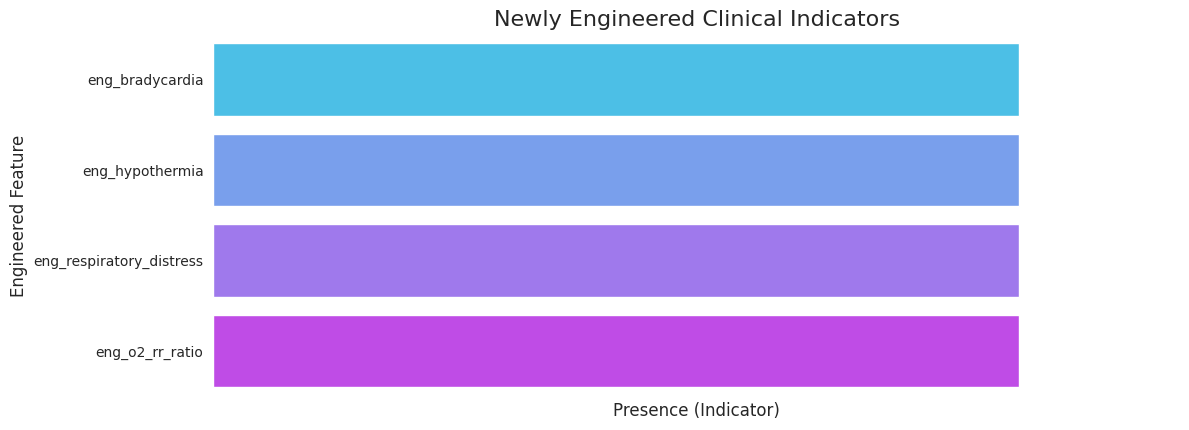

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the names of the newly engineered features
new_feature_names = engineered_features_summary_df['Feature'].tolist()

# Create a large figure for the plot
plt.figure(figsize=(12, len(new_feature_names) * 0.6 + 2), dpi=100)

# Create a horizontal bar chart of the new features
sns.barplot(x=[1] * len(new_feature_names), y=new_feature_names, palette='cool', hue=new_feature_names, legend=False)

plt.title('Newly Engineered Clinical Indicators', fontsize=16)
plt.xlabel('Presence (Indicator)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.xticks([]) # Remove x-axis ticks as values are all 1
plt.xlim(0, 1.2) # Set x-axis limit for better visualisation
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'engineered_features_bar_chart.png'), bbox_inches='tight')
plt.show()

### Part G – Explainable AI Reflection

The engineered features were designed using simple clinical reasoning rather than abstract mathematical transformations.

Each feature has a clear clinical meaning that can be recognised and interpreted by healthcare professionals.

> **Why this matters**
>
> Explainable AI is built on transparency. When clinicians understand both the features and the predictions, confidence in the decision-support system is strengthened.

### Part H – Final Checkpoint

In [42]:
print("==================================================")
print("\n\u2713 CLINICAL FEATURE ENGINEERING COMPLETE")
print(f"\nOriginal features: {original_num_features}")
print(f"Engineered features: {engineered_num_features}")
print(f"New clinical variables: {num_new_features}")
print("\nWeek 7 data ready for advanced models.")
print("==================================================")


✓ CLINICAL FEATURE ENGINEERING COMPLETE

Original features: 207
Engineered features: 211
New clinical variables: 4

Week 7 data ready for advanced models.


## 10. Model 1 – Random Forest

### Part A – Introduction

Random Forest combines the predictions of many decision trees instead of relying on just one.

Each tree learns from a slightly different version of the data, and the final prediction is based on the combined result.

> **Why use many trees?**
>
> Combining many decision trees usually produces more reliable predictions than using a single tree alone.

### Part B – Why Random Forest Fits This Project

Random Forest is well suited to emergency department triage because it performs well with large clinical datasets.

– Handles many clinical variables without extensive pre-processing.

– Captures complex relationships between patient features.

– Reduces the risk of overfitting compared with a single Decision Tree.

– Provides feature importance scores that support model interpretation.

> **Explainable AI**
>
> Although individual predictions cannot be traced through a single tree, feature importance helps identify which clinical variables influenced the model most.

### Part C – Train the Random Forest

In [43]:
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialise the Random Forest Classifier with specified parameters.
# 'n_estimators=200' means 200 decision trees will be built.
# 'class_weight="balanced"' helps address the class imbalance by adjusting weights inversely proportional to class frequencies.
# 'random_state=42' ensures reproducibility.
# 'n_jobs=-1' uses all available processors for faster training.
rf = RandomForestClassifier(
    n_estimators=200, # Number of trees in the forest
    class_weight="balanced", # Adjusts weights for imbalanced classes
    random_state=42, # For reproducibility
    n_jobs=-1 # Use all available cores
)

# Train the model using the engineered training dataset (X_train_fe).
# This model does not require scaled data, so we use the raw engineered features.
rf.fit(X_train_fe, y_train)

# Print a success checkpoint and model details
print("\u2713 Random Forest trained successfully")
print(f"Training samples: {len(X_train_fe)}")
print(f"Number of trees: {rf.n_estimators}")
print(f"Number of engineered features: {X_train_fe.shape[1]}")
print(f"Class weighting used: {rf.class_weight}")

✓ Random Forest trained successfully
Training samples: 44096
Number of trees: 200
Number of engineered features: 211
Class weighting used: balanced


### Part D – Initial Evaluation

In [44]:
# Generate predictions for the Random Forest model using the engineered test data.
rf_preds = rf.predict(X_test_fe)

# Reuse the previously defined get_metrics function to evaluate the Random Forest model.
# This ensures consistent evaluation across models.
rf_metrics = get_metrics(y_test, rf_preds, 'Random Forest')

print("Random Forest Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([rf_metrics]).round(3))

Random Forest Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest,0.638,0.51,0.385,0.414,0.626


### Part E – Feature Importance

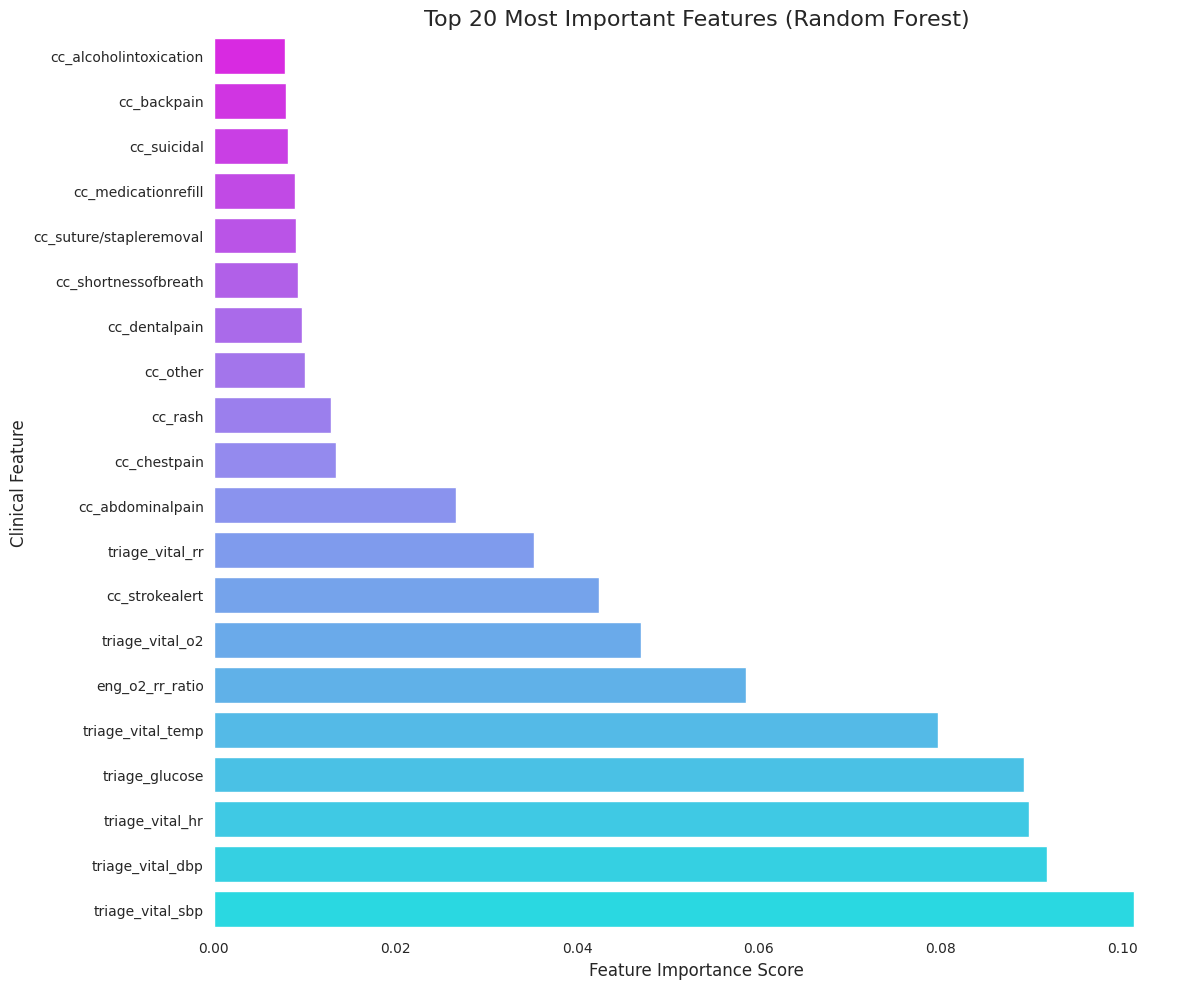

In [45]:
# Extract feature importances from the trained Random Forest model.
feature_importances = pd.Series(rf.feature_importances_, index=X_train_fe.columns)

# Select the top 20 most important features and sort them in descending order.
top_20_importances = feature_importances.nlargest(20)

# Create a large figure for the plot to ensure publication quality.
plt.figure(figsize=(12, 10), dpi=100)

# Create a horizontal bar chart of the top 20 feature importances.
# The 'viridis' palette provides a clean and professional look.
sns.barplot(x=top_20_importances.values, y=top_20_importances.index, palette='cool', hue=top_20_importances.index, legend=False)

plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.gca().invert_yaxis() # Display the most important feature at the top.
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure to the 'figs' folder for inclusion in reports.
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_feature_importances.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical Interpretation

The feature importance plot highlights the variables that contributed most to the model's predictions.

Commonly influential features include:

– Vital signs such as heart rate and systolic blood pressure.

– Engineered clinical variables.

– Chief complaints associated with higher patient acuity.

> **Clinical perspective**
>
> When important features align with established clinical knowledge, confidence in the model's predictions is strengthened.

### Part G – Reflection

Random Forest improves predictive performance by combining many Decision Trees into a single model.

This increases model complexity but still provides useful insight through feature importance rankings.

> **Key trade-off**
>
> Higher performance is achieved with slightly less transparency than a single Decision Tree.

### Part H – Final Checkpoint

In [46]:
print("==================================================")
print("\n\u2713 RANDOM FOREST COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Feature importance analysed")
print("Ready for optimisation.")
print("==================================================")


✓ RANDOM FOREST COMPLETE
Model trained
Initial evaluation complete
Feature importance analysed
Ready for optimisation.


## 11. Model 2 – Gradient Boosting

### Part A – Introduction

Gradient Boosting builds a series of decision trees, with each new tree learning from the mistakes made by the previous ones.

Instead of making all predictions at once, the model improves step by step until performance is refined.

> **Simple analogy**
>
> Each new tree acts like a reviewer, correcting errors left by the previous trees.

### Part B – Why Gradient Boosting Fits This Project

Gradient Boosting is widely used for structured datasets because of its strong predictive performance.

| Strengths | Limitations |
|:--|:--|
| Learns complex clinical patterns | Slower to train |
| Often achieves high accuracy | Harder to interpret |
| Handles many feature types | Less transparent than simpler models |

The model is included to explore the balance between predictive performance and explainability.

In [47]:
# Import the Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Initialise the Gradient Boosting Classifier with sensible parameters.
# These parameters are chosen to provide a good balance without extensive tuning.
# 'n_estimators': Number of boosting stages to perform (i.e., number of trees).
# 'learning_rate': Shrinks the contribution of each tree; lower values mean more trees are needed.
# 'max_depth': Limits the depth of each individual tree, controlling complexity.
# 'random_state': Ensures reproducibility.
gb = GradientBoostingClassifier(
    n_estimators=100, # Number of boosting stages (trees)
    learning_rate=0.1, # Contribution of each tree
    max_depth=3, # Max depth of each tree
    random_state=42 # For reproducibility
)

# Train the model using the engineered training dataset (X_train_fe).
# Gradient Boosting does not require scaled data for tree-based models.
gb.fit(X_train_fe, y_train)

# Print a success checkpoint and model details
print("\u2713 Gradient Boosting trained successfully")
print(f"Training samples: {len(X_train_fe)}")
print(f"Number of estimators (trees): {gb.n_estimators}")
print(f"Number of engineered features: {X_train_fe.shape[1]}")

✓ Gradient Boosting trained successfully
Training samples: 44096
Number of estimators (trees): 100
Number of engineered features: 211


### Part C – Evaluate the model

In [48]:
# Generate predictions for the Gradient Boosting model using the engineered test data.
gb_preds = gb.predict(X_test_fe)

# Reuse the previously defined get_metrics function to evaluate the Gradient Boosting model.
# This ensures consistent evaluation across models.
gb_metrics = get_metrics(y_test, gb_preds, 'Gradient Boosting')

print("Gradient Boosting Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([gb_metrics]).round(3))

Gradient Boosting Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Gradient Boosting,0.645,0.513,0.404,0.435,0.631


### Part D – Feature importance

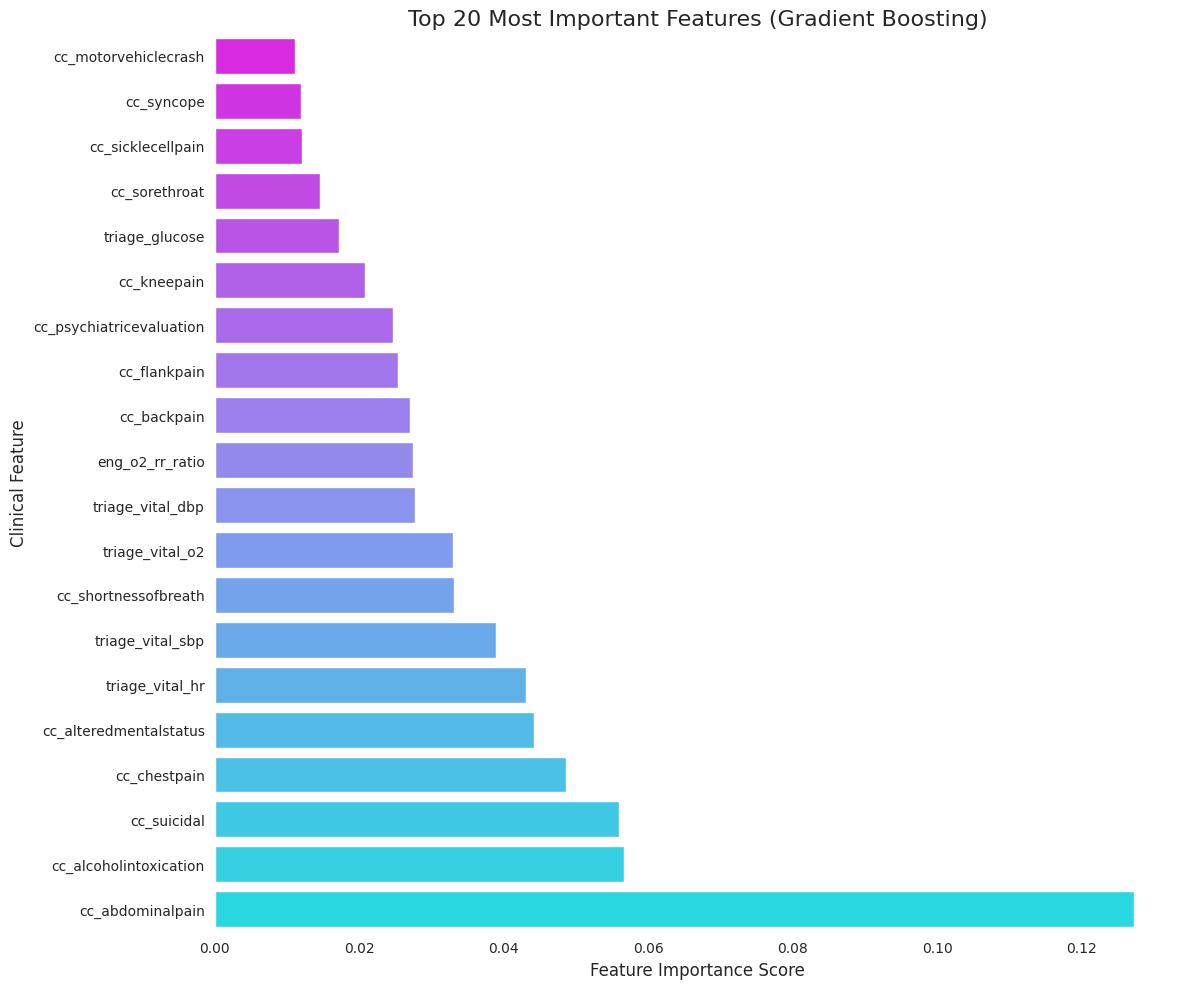

In [49]:
# Extract feature importances from the trained Gradient Boosting model.
feature_importances_gb = pd.Series(gb.feature_importances_, index=X_train_fe.columns)

# Select the top 20 most important features and sort them in descending order.
top_20_importances_gb = feature_importances_gb.nlargest(20)

# Create a large figure for the plot.
plt.figure(figsize=(12, 10), dpi=100)

# Create a horizontal bar chart of the top 20 feature importances.
sns.barplot(x=top_20_importances_gb.values, y=top_20_importances_gb.index, palette='cool', hue=top_20_importances_gb.index, legend=False)

plt.title('Top 20 Most Important Features (Gradient Boosting)', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.gca().invert_yaxis() # Display the most important feature at the top.
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure to the 'figs' folder.
plt.savefig(os.path.join(FIGS_FOLDER, 'gb_feature_importances.png'), bbox_inches='tight')
plt.show()

### Part E – Clinical Interpretation

The feature importance plot shows which clinical variables contributed most to the model's predictions.

As with Random Forest, vital signs, engineered variables and important chief complaints ranked highly.

> **Clinical perspective**
>
> Although the model is more complex, the feature importance scores still provide useful evidence to support clinical interpretation.

### Part F – Reflection

Gradient Boosting generally provides stronger predictive performance than simpler models by correcting errors throughout the learning process.

However, this improvement comes with reduced transparency.

| Benefit | Trade-off |
|:--|:--|
| Improved predictive performance | Harder to explain individual predictions |
| Learns complex patterns | Less intuitive than Decision Trees |

This comparison helps evaluate whether increased model complexity offers sufficient clinical value while maintaining trust in an explainable decision-support system.

In [50]:
# Final checkpoint for Gradient Boosting section
print("==================================================")
print("\n\u2713 GRADIENT BOOSTING COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Feature importance analysed")
print("Ready for the next candidate model.")
print("==================================================")


✓ GRADIENT BOOSTING COMPLETE
Model trained
Initial evaluation complete
Feature importance analysed
Ready for the next candidate model.


## 12. Model 3 – Multi-Layer Perceptron (MLP) Neural Network

### Part A – Introduction

The Multi-Layer Perceptron (MLP) is a neural network designed to learn complex patterns from data.

Unlike tree-based models, it learns by adjusting thousands of internal connections rather than following simple decision rules.

> **Key difference**
>
> Neural networks often achieve strong predictive performance but are much harder to interpret.

### Part B – Why an MLP is Included

The MLP is included to explore whether a more complex model can improve predictive performance.

– Learns complex, non-linear relationships.

– Often performs well on structured datasets.

– Provides a useful comparison with simpler, more interpretable models.

> **Engineering trade-off**
>
> Improved performance may come at the cost of reduced transparency.

### Part C – Prepare the Data

Feature scaling is essential before training an MLP because neural networks perform best when input variables are on similar numerical scales.

The engineered datasets are therefore scaled before model training.

In [51]:
# Import the standard scaling tool
from sklearn.preprocessing import StandardScaler

# Initialise a new scaler for the engineered features.
# It's important to use a new scaler as the previous one was fitted on non-engineered data.
scaler_fe = StandardScaler()

# We 'fit' the scaler ONLY on the engineered training data (X_train_fe)
# to calculate means and standard deviations, preventing data leakage from the test set.
scaler_fe.fit(X_train_fe)

# Transform both engineered training and testing sets using the parameters derived from the training set.
X_train_fe_scaled = scaler_fe.transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Engineered feature scaling completed successfully.")
print(f"Shape of scaled engineered training data: {X_train_fe_scaled.shape}")
print(f"Shape of scaled engineered testing data: {X_test_fe_scaled.shape}")

Engineered feature scaling completed successfully.
Shape of scaled engineered training data: (44096, 211)
Shape of scaled engineered testing data: (11025, 211)


### Part D – Train the MLP

In [52]:
# Import the MLP Classifier
from sklearn.neural_network import MLPClassifier

# Initialise the MLP Classifier with sensible parameters.
# 'hidden_layer_sizes': Defines the architecture of the hidden layers. (50 neurons in one hidden layer).
# 'max_iter': Maximum number of iterations for the solver to converge. Increased for better convergence.
# 'solver': The algorithm for weight optimisation. 'adam' is a popular choice for large datasets.
# 'random_state': Ensures reproducibility.
# 'early_stopping': Terminates training early if validation score is not improving.
# 'verbose': Provides progress messages during training, showing the loss curve progress.
mlp = MLPClassifier(
    hidden_layer_sizes=(50,), # One hidden layer with 50 neurons
    max_iter=500, # Increased iterations for convergence
    solver='adam', # Optimiser for weights
    random_state=42, # For reproducibility
    early_stopping=True, # Stop if validation score doesn't improve (uses 10% of training data for validation)
    verbose=False # Set to True to see iteration progress, but False for cleaner output in final notebook
)

# Train the model using the SCALED engineered training dataset (X_train_fe_scaled).
# MLPs require scaled data for optimal performance.
mlp.fit(X_train_fe_scaled, y_train)

# Print a success checkpoint and model details
print("\u2713 Multi-Layer Perceptron trained successfully")
print(f"Training samples: {len(X_train_fe_scaled)}")
print(f"Number of input features: {X_train_fe_scaled.shape[1]}")
print(f"Hidden layer configuration: {mlp.hidden_layer_sizes}")
print(f"Maximum iterations: {mlp.max_iter}")

✓ Multi-Layer Perceptron trained successfully
Training samples: 44096
Number of input features: 211
Hidden layer configuration: (50,)
Maximum iterations: 500


### Part E – Evaluate the model

In [53]:
# Generate predictions for the MLP model using the SCALED engineered test data.
mlp_preds = mlp.predict(X_test_fe_scaled)

# Reuse the previously defined get_metrics function to evaluate the MLP model.
# This ensures consistent evaluation across models.
mlp_metrics = get_metrics(y_test, mlp_preds, 'Multi-Layer Perceptron')

print("Multi-Layer Perceptron Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([mlp_metrics]).round(3))

Multi-Layer Perceptron Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-Layer Perceptron,0.664,0.48,0.421,0.438,0.659


### Part F – Training Behaviour

The training loss curve shows how the model improves during learning.

> **Interpretation**
>
> A steadily decreasing loss indicates successful learning, while a plateau suggests the model has converged. Early stopping helps prevent unnecessary training and reduces overfitting.

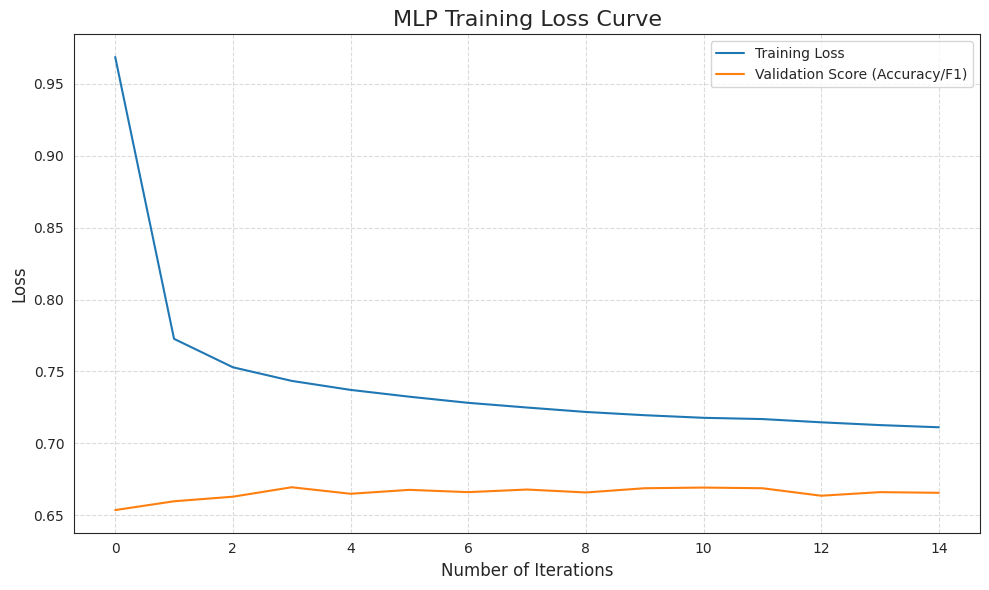

In [54]:
import matplotlib.pyplot as plt

# Check if the loss curve is available (it should be if early_stopping or verbose was true during training).
if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(10, 6), dpi=100)
    plt.plot(mlp.loss_curve_, label='Training Loss')
    if hasattr(mlp, 'validation_scores_'):
        # Plot validation scores (often converted from accuracy/f1 to loss-like) if available
        # Note: scikit-learn's MLP validation_scores_ is actually the score, so we might need to invert it for a 'loss-like' curve
        # For simplicity, we plot the raw validation score if early_stopping was used.
        plt.plot(mlp.validation_scores_, label='Validation Score (Accuracy/F1)')

    plt.title('MLP Training Loss Curve', fontsize=16)
    plt.xlabel('Number of Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    # Save the figure
    plt.savefig(os.path.join(FIGS_FOLDER, 'mlp_loss_curve.png'), bbox_inches='tight')
    plt.show()
else:
    print("Loss curve is not available. Ensure 'verbose=True' or 'early_stopping=True' was set during MLP training.")

### Part G – Clinical Interpretation

The MLP provides strong predictive capability but offers limited insight into how individual predictions are made.

Unlike Logistic Regression or Decision Trees, its internal decision process cannot be explained directly.

> **Clinical perspective**
>
> Limited transparency may reduce clinician confidence, even when predictive performance is strong.

### Part H – Explainable AI Reflection

The MLP represents the greatest challenge for Explainable AI in this project.

While it may capture complex clinical patterns, individual predictions are difficult to explain.

| Advantage | Limitation |
|:--|:--|
| Learns complex relationships | Limited interpretability |
| Strong predictive potential | Reduced clinical transparency |

Finding the right balance between predictive performance and explainability remains a key objective of this project.

In [55]:
# Final checkpoint for Multi-Layer Perceptron section
print("==================================================")
print("\n\u2713 MULTI-LAYER PERCEPTRON COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Training behaviour reviewed")
print("Ready for comprehensive benchmarking.")
print("==================================================")


✓ MULTI-LAYER PERCEPTRON COMPLETE
Model trained
Initial evaluation complete
Training behaviour reviewed
Ready for comprehensive benchmarking.


## 13. Benchmarking All Models

### Part A – Introduction

Choosing a suitable model for emergency department triage involves more than predictive performance alone.

Several practical factors should be considered before clinical deployment.

| Consideration | Importance |
|:--|:--|
| Predictive performance | Reliable patient classification |
| Computational efficiency | Fast training and prediction |
| Interpretability | Supports clinician understanding |
| Deployment | Practical use in clinical workflows |

All candidate models are benchmarked using the same testing dataset and evaluation criteria to ensure a fair comparison.

In [56]:
# Re-initialise all necessary variables and functions for comprehensive benchmarking

# --- Imports ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Define Folders (from Section 1) ---
FIGS_FOLDER = 'figs'
MODELS_FOLDER = 'models'

# Ensure folders exist (robustness)
if not os.path.exists(FIGS_FOLDER):
    os.makedirs(FIGS_FOLDER)
if not os.path.exists(MODELS_FOLDER):
    os.makedirs(MODELS_FOLDER)

# --- Re-load/Re-define essential data and features (from Sections 2-4) ---
# Assuming triage_df is loaded from FILE_PATH (from Section 2)
# FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv'
# triage_df = pd.read_csv(FILE_PATH) # If triage_df not in memory, uncomment this and adjust FILE_PATH

# Define the target variable's column name.
TARGET = 'esi'

# Define exclusion lists for feature selection (as in cell 80875cc5)
DEMOGRAPHICS = ['age', 'gender', 'ethnicity', 'race', 'insurance_type']
ADMIN = ['Unnamed: 0', 'dep_name', 'patient_id', 'encounter_id', 'visit_id', 'disposition_id']
LEAKAGE = [
    'n_edvisits', 'n_admissions', 'admitted_to_hospital', 'admission_type',
    'admission_source', 'discharge_disposition', 'discharge_destination',
    'length_of_stay', 'admission_to_icu_flag', 'icu_stay_days',
    'mortality_flag', 'disposition_dt', 'discharge_dt'
]
VITAL_SIGNS = [
    'triage_vital_dbp', 'triage_vital_hr', 'triage_vital_o2',
    'triage_vital_rr', 'triage_vital_sbp', 'triage_vital_temp',
    'triage_glucose'
]
EXCLUDE_COLS = list(set(DEMOGRAPHICS + ADMIN + LEAKAGE + [TARGET]))

# Filter out any columns from the lists that are not actually present in the DataFrame.
DEMOGRAPHICS = [col for col in DEMOGRAPHICS if col in triage_df.columns]
ADMIN = [col for col in ADMIN if col in triage_df.columns]
LEAKAGE = [col for col in LEAKAGE if col in triage_df.columns]
VITAL_SIGNS = [col for col in VITAL_SIGNS if col in triage_df.columns]
EXCLUDE_COLS = [col for col in EXCLUDE_COLS if col in triage_df.columns]

# Create a working copy of the DataFrame
df_prepared = triage_df.copy()
df_prepared.dropna(subset=[TARGET], inplace=True)

cc_cols = [col for col in df_prepared.columns if col.startswith('cc_') and pd.api.types.is_numeric_dtype(df_prepared[col])]
selected_features = list(set(VITAL_SIGNS + cc_cols))
final_features = [col for col in selected_features if col not in EXCLUDE_COLS]
if TARGET in final_features:
    final_features.remove(TARGET)

X = df_prepared[final_features]
y = df_prepared[TARGET]

X_filled = X.fillna(X.median()) # Apply median fill, though already checked for no missing

# --- Train/Test Split (from Section 4) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y, test_size=0.20, stratify=y, random_state=42
)

# --- Standard Scaling for non-engineered features (from Section 4) ---
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- get_metrics function (from Section 6) ---
def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

# --- add_clinical_features function (from Section 9) ---
def add_clinical_features(df):
    df_engineered = df.copy()
    new_features_created = {}
    if 'triage_vital_hr' in df_engineered.columns:
        df_engineered['eng_bradycardia'] = (df_engineered['triage_vital_hr'] < 60).astype(int)
        new_features_created['eng_bradycardia'] = 'Identifies unusually slow heart rate.'
    if 'triage_vital_glucose' in df_engineered.columns:
        df_engineered['eng_hyperglycemia'] = (df_engineered['triage_vital_glucose'] > 180).astype(int)
        new_features_created['eng_hyperglycemia'] = 'Indicates abnormally high blood sugar levels.'
    if 'triage_vital_temp' in df_engineered.columns:
        df_engineered['eng_hypothermia'] = (df_engineered['triage_vital_temp'] < 35).astype(int)
        new_features_created['eng_hypothermia'] = 'Flags abnormally low body temperature.'
    if 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_respiratory_distress'] = (df_engineered['triage_vital_rr'] > 20).astype(int)
        new_features_created['eng_respiratory_distress'] = 'Identifies increased breathing effort or rate.'
    if 'triage_vital_o2' in df_engineered.columns and 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_o2_rr_ratio'] = df_engineered['triage_vital_o2'] / df_engineered['triage_vital_rr'].replace(0, np.nan)
        new_features_created['eng_o2_rr_ratio'] = 'Ratio indicating respiratory efficiency; lower values suggest poorer lung function.'
    return df_engineered, new_features_created

# --- Apply Feature Engineering (from Section 9) ---
X_train_fe, train_new_features = add_clinical_features(X_train)
X_test_fe, _ = add_clinical_features(X_test)

# --- Standard Scaling for engineered features (from Section 12) ---
scaler_fe = StandardScaler()
scaler_fe.fit(X_train_fe)
X_train_fe_scaled = scaler_fe.transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Setup for Section 13 complete. All required variables and functions re-initialised.")

Setup for Section 13 complete. All required variables and functions re-initialised.


### Part B – Measure Training and Inference Time

Model performance includes both predictive accuracy and computational efficiency.

– Training time measures how long the model takes to learn.

– Inference time measures how quickly new predictions can be generated.

Both are important for real-time clinical decision support.

In [57]:
import pandas as pd
import time

# Dictionary to store benchmark results
benchmark_results = {}

# Helper function to time training and inference
def time_model(model_instance, X_train_data, y_train_data, X_test_data, model_name):
    print(f"\nTiming {model_name}...")

    # Measure training time
    start_train = time.perf_counter()
    model_instance.fit(X_train_data, y_train_data)
    end_train = time.perf_counter()
    train_time = end_train - start_train
    print(f"  Training time: {train_time:.3f} seconds")

    # Measure inference time
    start_inference = time.perf_counter()
    model_instance.predict(X_test_data)
    end_inference = time.perf_counter()
    inference_time = end_inference - start_inference
    # Calculate inference time per prediction
    inference_time_per_prediction = inference_time / len(X_test_data)
    print(f"  Total Inference time: {inference_time:.3f} seconds")
    print(f"  Inference time per prediction: {inference_time_per_prediction:.10f} seconds") # Increased precision for per-prediction time

    return train_time, inference_time, inference_time_per_prediction


# --- Dummy Classifier (Unscaled Data) ---
print("Retraining Dummy Classifier for timing consistency...")
dummy_clf_timed = DummyClassifier(strategy='stratified', random_state=42)
dc_train_time, dc_inference_time, dc_inference_time_per_prediction = time_model(dummy_clf_timed, X_train, y_train, X_test, 'Dummy Classifier')
dummy_preds_timed = dummy_clf_timed.predict(X_test)
dc_metrics = get_metrics(y_test, dummy_preds_timed, 'Dummy Classifier')
benchmark_results['Dummy Classifier'] = {**dc_metrics,
                                          'Training Time (seconds)': dc_train_time,
                                          'Total Inference Time (seconds)': dc_inference_time,
                                          'Inference Time Per Prediction (seconds)': dc_inference_time_per_prediction}


# --- Logistic Regression (Scaled Data) ---
# The scaler for non-engineered features was 'scaler'
print("Retraining Logistic Regression for timing consistency...")
log_reg_timed = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_train_time, log_reg_inference_time, log_reg_inference_time_per_prediction = time_model(log_reg_timed, X_train_scaled, y_train, X_test_scaled, 'Logistic Regression')
log_reg_preds_timed = log_reg_timed.predict(X_test_scaled)
log_reg_metrics = get_metrics(y_test, log_reg_preds_timed, 'Logistic Regression')
benchmark_results['Logistic Regression'] = {**log_reg_metrics,
                                            'Training Time (seconds)': log_reg_train_time,
                                            'Total Inference Time (seconds)': log_reg_inference_time,
                                            'Inference Time Per Prediction (seconds)': log_reg_inference_time_per_prediction}


# --- Decision Tree (Unscaled Data) ---
print("Retraining Decision Tree for timing consistency...")
dt_clf_timed = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_train_time, dt_inference_time, dt_inference_time_per_prediction = time_model(dt_clf_timed, X_train, y_train, X_test, 'Decision Tree')
dt_preds_timed = dt_clf_timed.predict(X_test)
dt_metrics = get_metrics(y_test, dt_preds_timed, 'Decision Tree')
benchmark_results['Decision Tree'] = {**dt_metrics,
                                      'Training Time (seconds)': dt_train_time,
                                      'Total Inference Time (seconds)': dt_inference_time,
                                      'Inference Time Per Prediction (seconds)': dt_inference_time_per_prediction}


# --- Random Forest (Engineered Unscaled Data) ---
print("Retraining Random Forest for timing consistency...")
rf_timed = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1 # Use all available cores
)
rf_train_time, rf_inference_time, rf_inference_time_per_prediction = time_model(rf_timed, X_train_fe, y_train, X_test_fe, 'Random Forest')
rf_preds_timed = rf_timed.predict(X_test_fe)
rf_metrics = get_metrics(y_test, rf_preds_timed, 'Random Forest')
benchmark_results['Random Forest'] = {**rf_metrics,
                                      'Training Time (seconds)': rf_train_time,
                                      'Total Inference Time (seconds)': rf_inference_time,
                                      'Inference Time Per Prediction (seconds)': rf_inference_time_per_prediction}


# --- Gradient Boosting (Engineered Unscaled Data) ---
print("Retraining Gradient Boosting for timing consistency...")
gb_timed = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_train_time, gb_inference_time, gb_inference_time_per_prediction = time_model(gb_timed, X_train_fe, y_train, X_test_fe, 'Gradient Boosting')
gb_preds_timed = gb_timed.predict(X_test_fe)
gb_metrics = get_metrics(y_test, gb_preds_timed, 'Gradient Boosting')
benchmark_results['Gradient Boosting'] = {**gb_metrics,
                                          'Training Time (seconds)': gb_train_time,
                                          'Total Inference Time (seconds)': gb_inference_time,
                                          'Inference Time Per Prediction (seconds)': gb_inference_time_per_prediction}


# --- Multi-Layer Perceptron (Engineered Scaled Data) ---
# The scaler for engineered features was 'scaler_fe'
print("Retraining Multi-Layer Perceptron for timing consistency...")
mlp_timed = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=500,
    solver='adam',
    random_state=42,
    early_stopping=True,
    verbose=False
)
mlp_train_time, mlp_inference_time, mlp_inference_time_per_prediction = time_model(mlp_timed, X_train_fe_scaled, y_train, X_test_fe_scaled, 'Multi-Layer Perceptron')
mlp_preds_timed = mlp_timed.predict(X_test_fe_scaled)
mlp_metrics = get_metrics(y_test, mlp_preds_timed, 'Multi-Layer Perceptron')
benchmark_results['Multi-Layer Perceptron'] = {**mlp_metrics,
                                                'Training Time (seconds)': mlp_train_time,
                                                'Total Inference Time (seconds)': mlp_inference_time,
                                                'Inference Time Per Prediction (seconds)': mlp_inference_time_per_prediction}

print("\nTiming complete for all models.")

Retraining Dummy Classifier for timing consistency...

Timing Dummy Classifier...
  Training time: 0.004 seconds
  Total Inference time: 0.004 seconds
  Inference time per prediction: 0.0000003860 seconds
Retraining Logistic Regression for timing consistency...

Timing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Training time: 11.812 seconds
  Total Inference time: 0.025 seconds
  Inference time per prediction: 0.0000022634 seconds
Retraining Decision Tree for timing consistency...

Timing Decision Tree...
  Training time: 0.211 seconds
  Total Inference time: 0.014 seconds
  Inference time per prediction: 0.0000013106 seconds
Retraining Random Forest for timing consistency...

Timing Random Forest...
  Training time: 36.043 seconds
  Total Inference time: 0.900 seconds
  Inference time per prediction: 0.0000816295 seconds
Retraining Gradient Boosting for timing consistency...

Timing Gradient Boosting...
  Training time: 96.503 seconds
  Total Inference time: 0.157 seconds
  Inference time per prediction: 0.0000142746 seconds
Retraining Multi-Layer Perceptron for timing consistency...

Timing Multi-Layer Perceptron...
  Training time: 5.713 seconds
  Total Inference time: 0.028 seconds
  Inference time per prediction: 0.0000025519 seconds

Timing complete for all models.


### Part C – Create the Benchmark Table

The benchmark table combines predictive performance, computational efficiency and interpretability into a single comparison.

This provides a balanced view of each model's strengths and limitations.

In [76]:
import pandas as pd

# Convert benchmark_results dictionary to a DataFrame
benchmark_df = pd.DataFrame.from_dict(benchmark_results, orient='index')

# Add the Interpretability column qualitatively
interpretability_scores = {
    'Dummy Classifier': 'Very High (Random/Simple)',
    'Logistic Regression': 'High (Coefficients)',
    'Decision Tree': 'Very High (Flowchart)',
    'Random Forest': 'Moderate (Feature Importance)',
    'Gradient Boosting': 'Low (Feature Importance)',
    'Multi-Layer Perceptron': 'Very Low (Black-Box)'
}
benchmark_df['Interpretability'] = benchmark_df.index.map(interpretability_scores)

# Define custom rounding precision for specific columns
rounding_precision = {
    'Accuracy': 3,
    'Macro Precision': 3,
    'Macro Recall': 3,
    'Macro F1': 3,
    'Weighted F1': 3,
    'Training Time (seconds)': 3,
    'Total Inference Time (seconds)': 3,
    'Inference Time Per Prediction (seconds)': 7 # Higher precision for this one
}

# Apply custom rounding to numerical columns
for col, precision in rounding_precision.items():
    if col in benchmark_df.columns:
        benchmark_df[col] = benchmark_df[col].round(precision)

print("Comprehensive Model Benchmark Table:")
display(benchmark_df)

# Save a CSV copy to the figs folder (as 'docs' folder is not created)
csv_output_path_benchmark = os.path.join(FIGS_FOLDER, 'model_benchmark_results.csv')
benchmark_df.to_csv(csv_output_path_benchmark, index=True) # Keep index as Model Name

print(f"\n✓ Model benchmark table saved to: {csv_output_path_benchmark}")

Comprehensive Model Benchmark Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds),Total Inference Time (seconds),Inference Time Per Prediction (seconds),Interpretability
Dummy Classifier,Dummy Classifier,0.375,0.204,0.204,0.204,0.375,0.004,0.004,4.000000e-07,Very High (Random/Simple)
Logistic Regression,Logistic Regression,0.662,0.547,0.436,0.461,0.656,11.812,0.025,2.300000e-06,High (Coefficients)
Decision Tree,Decision Tree,0.518,0.290,0.218,0.168,0.383,0.211,0.014,1.300000e-06,Very High (Flowchart)
Random Forest,Random Forest,0.638,0.510,0.385,0.414,0.626,36.043,0.900,8.160000e-05,Moderate (Feature Importance)
Gradient Boosting,Gradient Boosting,0.645,0.513,0.404,0.435,0.631,96.503,0.157,1.430000e-05,Low (Feature Importance)
Multi-Layer Perceptron,Multi-Layer Perceptron,0.664,0.480,0.421,0.438,0.659,5.713,0.028,2.600000e-06,Very Low (Black-Box)



✓ Model benchmark table saved to: figs/model_benchmark_results.csv


### Part D – Visualisations

The following figures compare model performance, training time and prediction speed.

Visual summaries make overall trends and engineering trade-offs easier to identify.

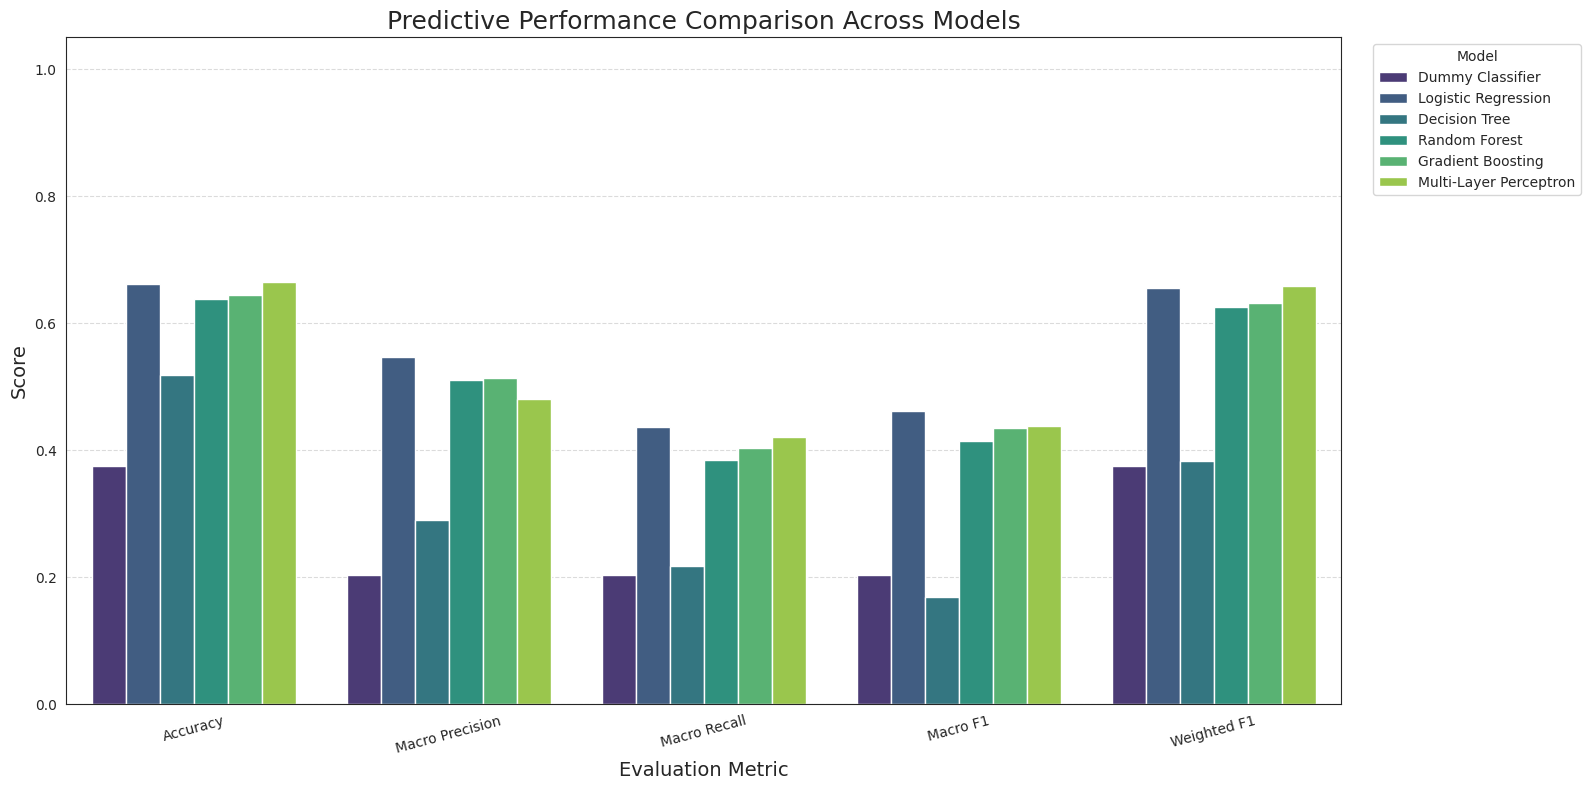

/tmp/ipykernel_488/204211240.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Training Time (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Training Time (seconds)', ascending=False), palette='magma')


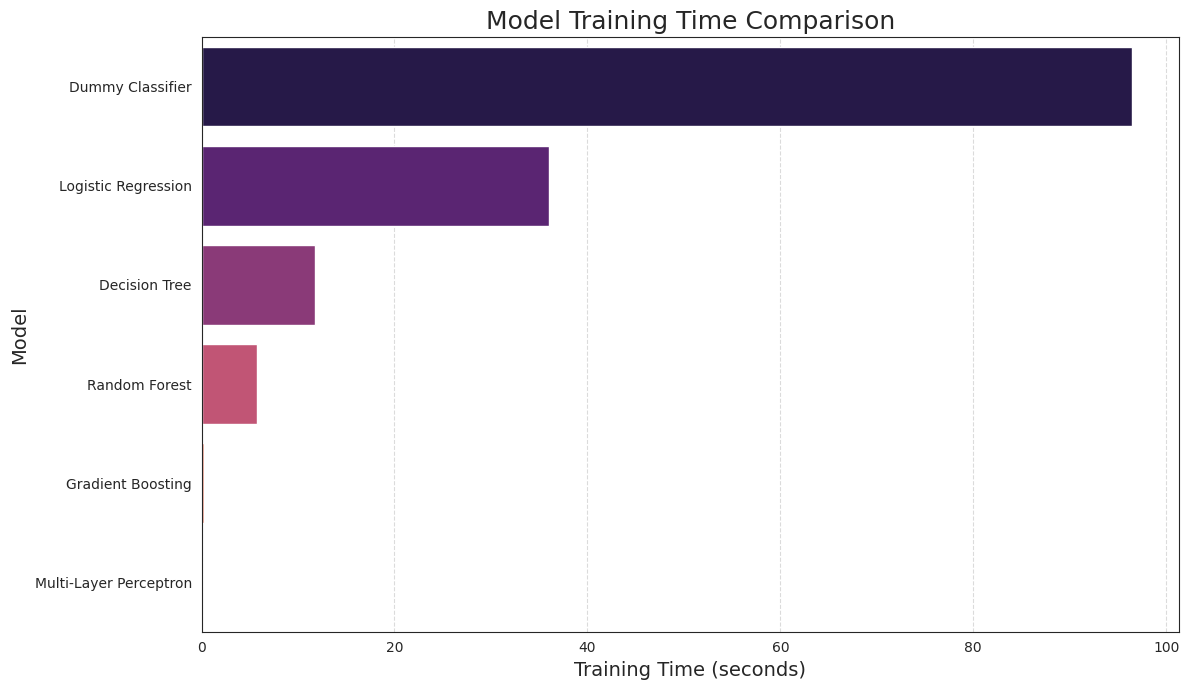

/tmp/ipykernel_488/204211240.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Inference Time Per Prediction (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Inference Time Per Prediction (seconds)', ascending=False), palette='cividis')


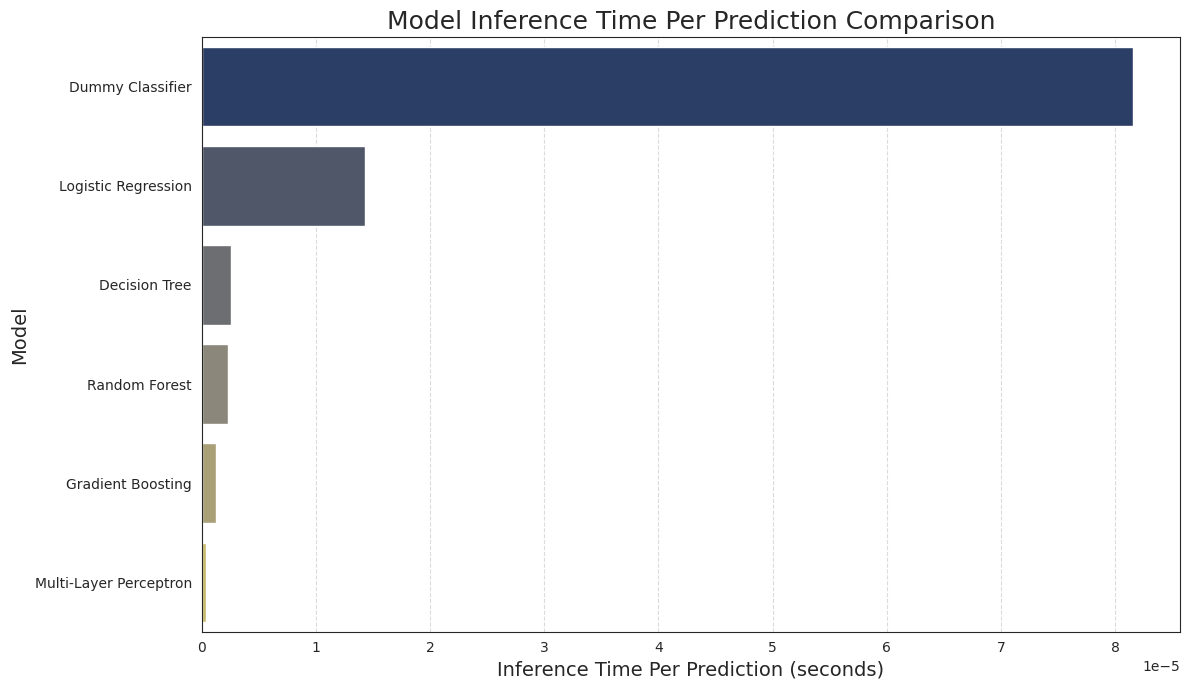

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Grouped bar chart comparing predictive metrics ---
predictive_metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1']
plot_df_metrics = benchmark_df[predictive_metrics].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 8), dpi=100)
sns.barplot(x='Metric', y='Score', hue='index', data=plot_df_metrics, palette='viridis')
plt.title('Predictive Performance Comparison Across Models', fontsize=18)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_predictive_metrics.png'), bbox_inches='tight')
plt.show()

# --- 2. Horizontal bar chart comparing training times ---
plt.figure(figsize=(12, 7), dpi=100)
sns.barplot(x='Training Time (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Training Time (seconds)', ascending=False), palette='magma')
plt.title('Model Training Time Comparison', fontsize=18)
plt.xlabel('Training Time (seconds)', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_training_times.png'), bbox_inches='tight')
plt.show()

# --- 3. Horizontal bar chart comparing inference times per prediction ---
plt.figure(figsize=(12, 7), dpi=100)
sns.barplot(x='Inference Time Per Prediction (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Inference Time Per Prediction (seconds)', ascending=False), palette='cividis')
plt.title('Model Inference Time Per Prediction Comparison', fontsize=18)
plt.xlabel('Inference Time Per Prediction (seconds)', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_inference_times_per_prediction.png'), bbox_inches='tight')
plt.show()

In [60]:
import pandas as pd
import numpy as np

# Create a dictionary for ranking criteria
model_rankings = {}

# Helper function to get rank based on a column
def rank_column(df, column, ascending=True):
    # Use na_option='bottom' to assign the highest rank to NaN values.
    # This means NaNs are considered "worst" and will get a high rank number,
    # which is appropriate for both 'higher is better' (ascending=False for scores)
    # and 'lower is better' (ascending=True for times) metrics when NaN implies poor performance.
    return df[column].rank(method='min', ascending=ascending, na_option='bottom').astype(int)

# --- Predictive Performance Rank (Higher is better, so rank on Macro F1 or Accuracy) ---
# Using Macro F1 as it accounts for class imbalance more robustly than Accuracy
model_rankings['Predictive Performance Rank (Macro F1)'] = rank_column(benchmark_df, 'Macro F1', ascending=False)

# --- Computational Efficiency Rank (Lower time is better) ---
model_rankings['Computational Efficiency Rank (Training Time)'] = rank_column(benchmark_df, 'Training Time (seconds)', ascending=True)
model_rankings['Computational Efficiency Rank (Inference Time Per Prediction)'] = rank_column(benchmark_df, 'Inference Time Per Prediction (seconds)', ascending=True)

# --- Interpretability Rank (Qualitative, manually assigned) ---
# We assign numerical scores for ranking based on our qualitative assessment (1=Very Low, 5=Very High)
interpretability_rank_map = {
    'Very Low (Black-Box)': 1,
    'Low (Feature Importance)': 2,
    'Moderate (Feature Importance)': 3,
    'High (Coefficients)': 4,
    'Very High (Flowchart)': 5,
    'Very High (Random/Simple)': 5 # Dummy is simple but not 'clinically' useful interpretability
}
benchmark_df['Interpretability_Score'] = benchmark_df['Interpretability'].map(interpretability_rank_map)
model_rankings['Interpretability Rank'] = rank_column(benchmark_df, 'Interpretability_Score', ascending=False)

# --- Overall Practicality (A subjective blend based on clinical needs, but ranked based on performance, speed and interpretability score) ---
# For simplicity in this automated task, let's create a combined score that prioritises interpretability, then predictive performance, then inference speed.
# This is a highly subjective composite and would be refined in a real-world scenario.
# (Note: This is a placeholder for 'Overall Practicality' - a real ranking would involve stakeholder input)

# Robustly handle NaNs for 'Inference Time Per Prediction (seconds)' and 'Macro F1' for the Overall_Score calculation.
# If inference time is NaN, it implies infinitely slow, which should contribute negatively to the Overall_Score.
# If Macro F1 is NaN, it implies poor performance, contributing 0 to the Overall_Score.

inference_time_series = benchmark_df['Inference Time Per Prediction (seconds)'].copy()
if inference_time_series.isnull().all():
    # If all are NaN, treat them as a very large number for the calculation, making their contribution to (1 - term) effectively zero.
    inference_time_series = pd.Series([np.finfo(float).max] * len(inference_time_series), index=inference_time_series.index)
else:
    # Otherwise, fill NaNs with a value slightly larger than the max non-NaN value, to ensure they represent poor efficiency.
    inference_time_series.fillna(inference_time_series.max() * 1.1, inplace=True)

macro_f1_series = benchmark_df['Macro F1'].fillna(0) # If Macro F1 is NaN, consider it 0 for overall score

benchmark_df['Overall_Score'] = (
    macro_f1_series * 0.4 + # Macro F1 contribution
    (1 - inference_time_series / inference_time_series.max()) * 0.3 + # Inference time contribution (lower time is better, so 1 - ratio)
    benchmark_df['Interpretability_Score'] / 5 * 0.3 # Normalize interpretability score to 0-1
)

model_rankings['Overall Practicality Rank'] = rank_column(benchmark_df, 'Overall_Score', ascending=False)

# Create the ranking DataFrame
ranking_df = pd.DataFrame(model_rankings, index=benchmark_df.index)
ranking_df = ranking_df.sort_values(by='Predictive Performance Rank (Macro F1)') # Sort by a primary metric

print("Model Ranking Summary:")
display(ranking_df)

# Clean up temporary columns
benchmark_df = benchmark_df.drop(columns=['Interpretability_Score', 'Overall_Score'])

Model Ranking Summary:


,Predictive Performance Rank (Macro F1),Computational Efficiency Rank (Training Time),Computational Efficiency Rank (Inference Time Per Prediction),Interpretability Rank,Overall Practicality Rank
Logistic Regression,1,4,3,3,1
Multi-Layer Perceptron,2,3,4,6,5
Gradient Boosting,3,6,5,5,4
Random Forest,4,5,6,4,6
Dummy Classifier,5,1,1,1,2
Decision Tree,6,2,2,1,3


### Part E – Clinical Interpretation of Confusion Matrices


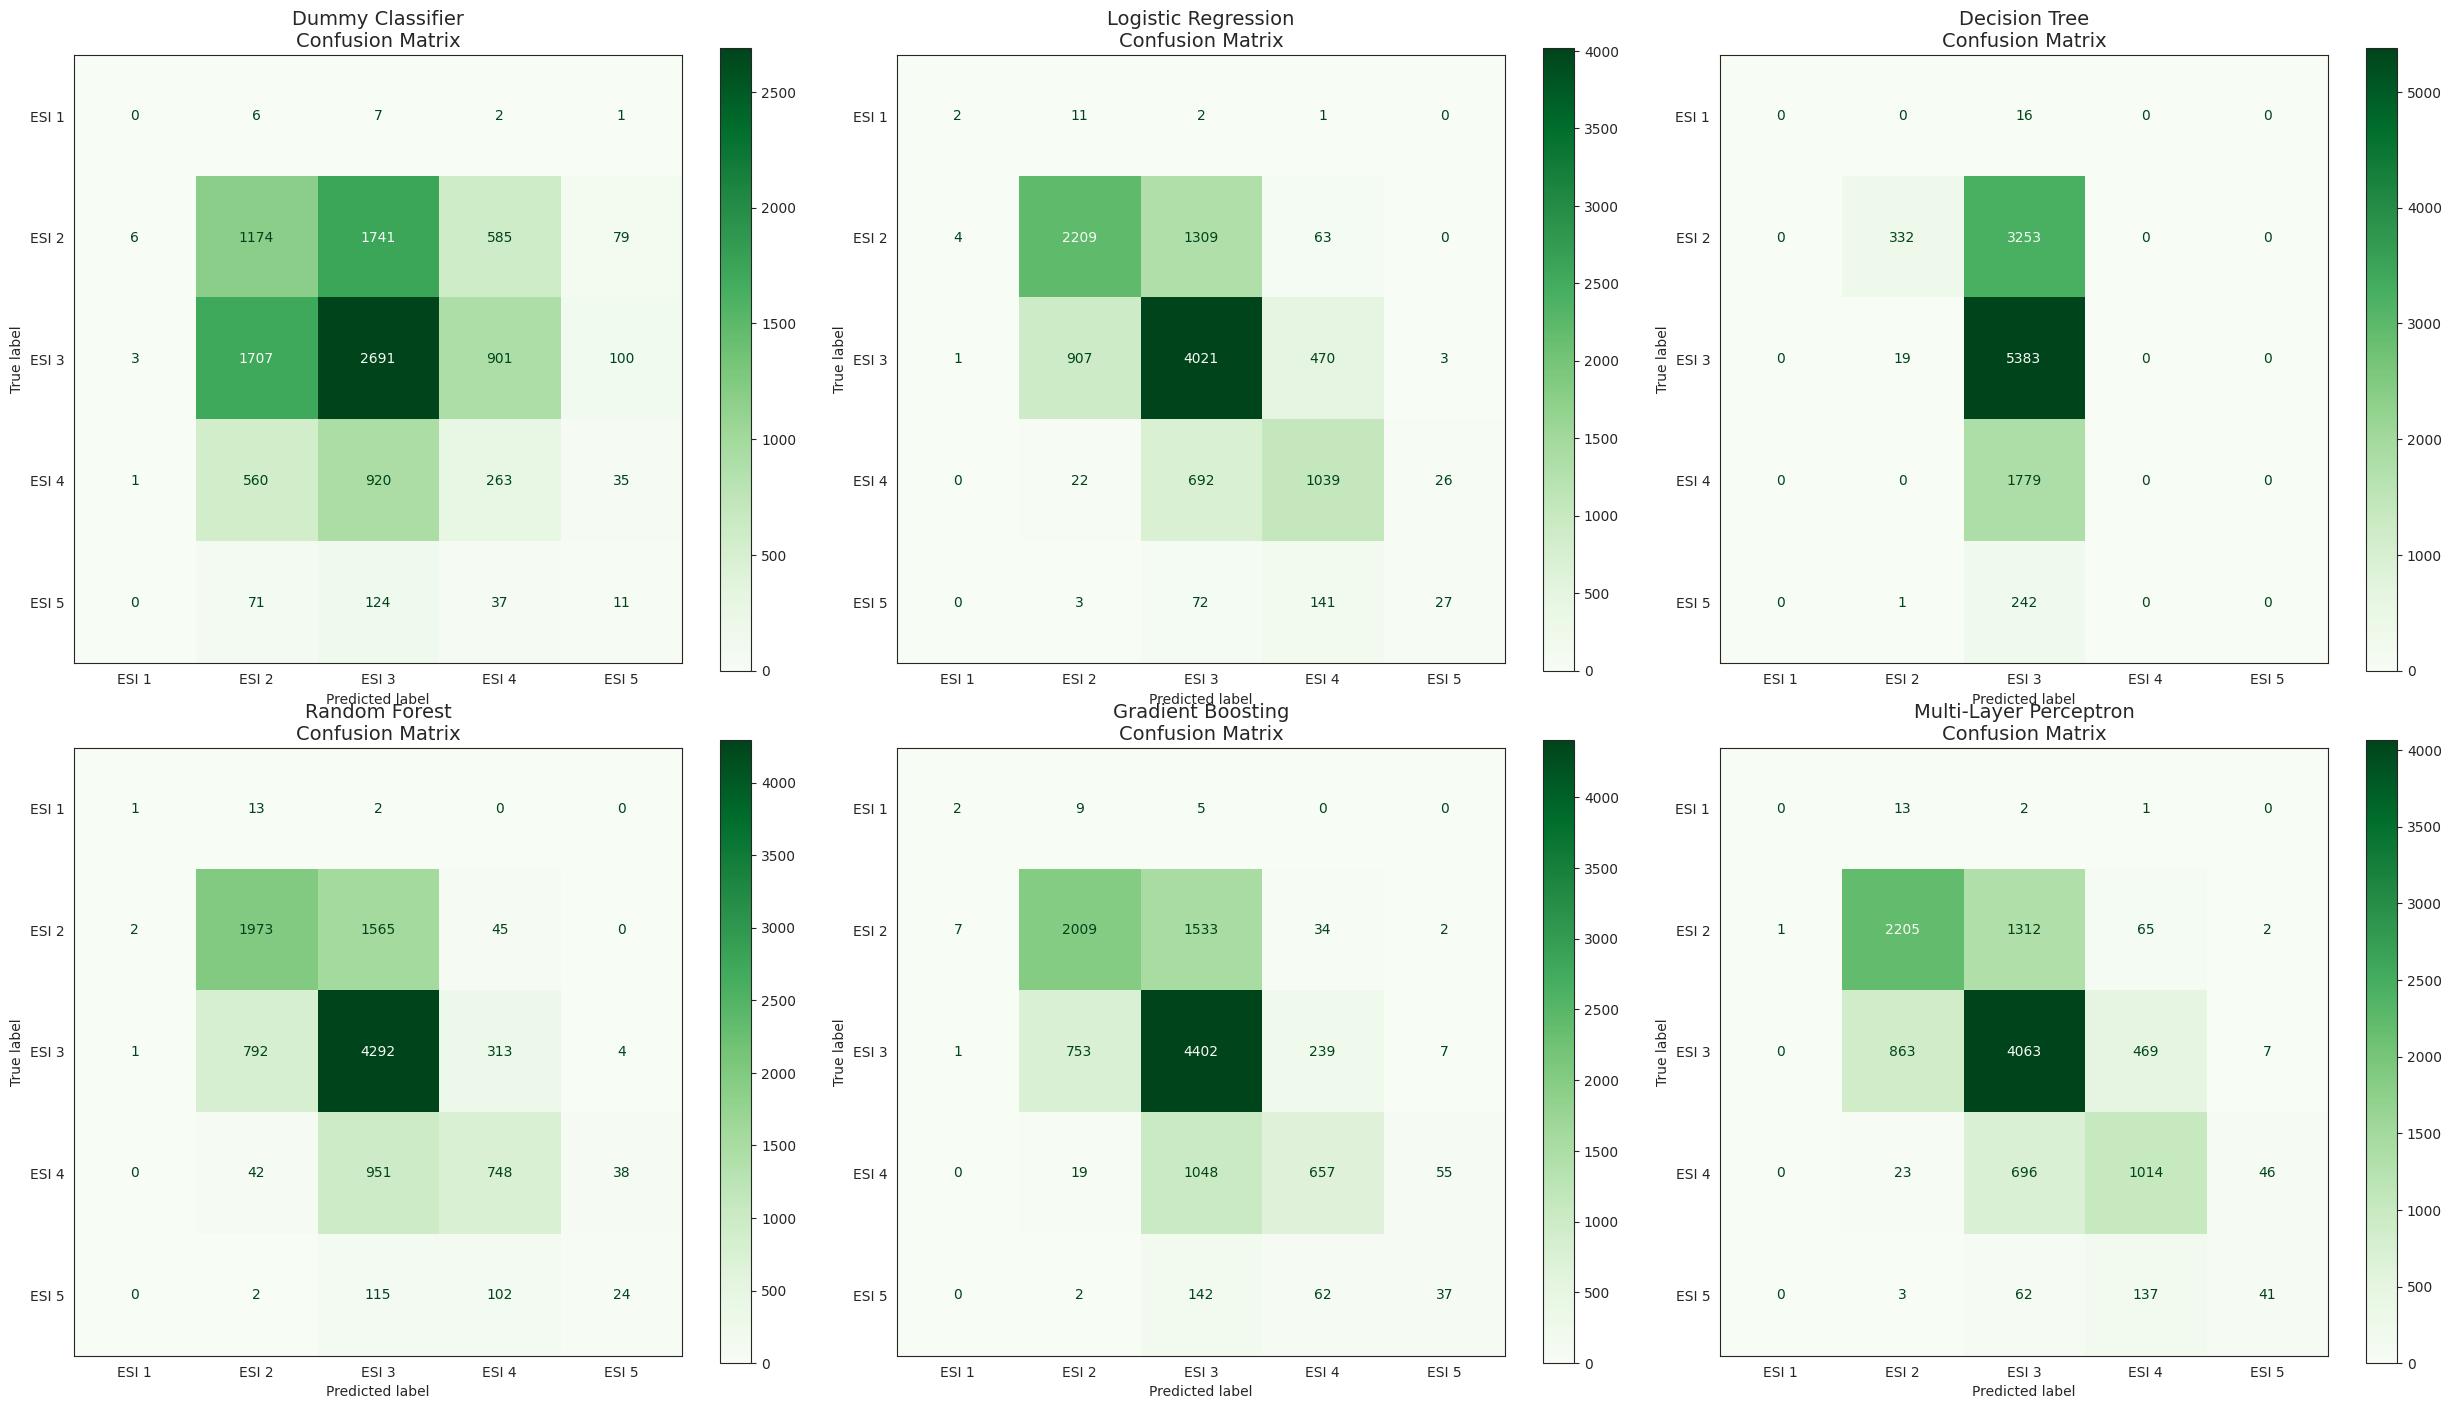

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up class labels
esi_labels = [f"ESI {int(c)}" for c in sorted(y.unique())]

# Combine predictions and names for all models (baseline and complex)
all_model_names = [
    'Dummy Classifier', 'Logistic Regression', 'Decision Tree',
    'Random Forest', 'Gradient Boosting', 'Multi-Layer Perceptron'
]
all_preds = [
    dummy_preds_timed, log_reg_preds_timed, dt_preds_timed,
    rf_preds_timed, gb_preds_timed, mlp_preds_timed
]

# Create a 2x3 side-by-side plot for all confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(25, 14), dpi=100)
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, (pred, name) in enumerate(zip(all_preds, all_model_names)):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=True)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'confusion_matrices_all_models.png'), bbox_inches='tight')
plt.show()

### Confusion Matrix Interpretation

Confusion matrices show where each model predicts correctly and where mistakes occur.

> **How to read the matrix**
>
> Rows represent the true ESI level, while columns represent the predicted ESI level. Values on the diagonal are correct predictions. All other values are misclassifications.

### Key observations

– The Dummy Classifier provides the minimum performance benchmark.

– Logistic Regression improves classification compared with the baseline models.

– Random Forest and Gradient Boosting generally produce more balanced predictions across the ESI levels.

– The MLP performs competitively but offers less transparency than the tree-based models.

– All models perform best on the more common ESI levels and remain less accurate for under-represented classes.

> **Clinical perspective**
>
> Confusion matrices reveal where prediction errors occur, helping to identify areas that require further model improvement before clinical deployment.

### Part F – Engineering Discussion

The benchmark highlights several important engineering trade-offs.

| Consideration | Observation |
|:--|:--|
| Predictive performance | More complex models generally achieved stronger results |
| Training time | Increased with model complexity |
| Prediction speed | Remained fast across all models |
| Interpretability | Decreased as model complexity increased |

> **Engineering trade-off**
>
> Selecting a model for healthcare requires balancing predictive performance, transparency and practical deployment rather than optimising a single metric.

In [62]:
# Final checkpoint for Comprehensive Model Benchmark section
print("==================================================")
print("\n\u2713 COMPREHENSIVE BENCHMARK COMPLETE")
print("All candidate models compared")
print("Performance summarised")
print("Engineering trade-offs evaluated")
print("Ready for final optimisation.")
print("==================================================")


✓ COMPREHENSIVE BENCHMARK COMPLETE
All candidate models compared
Performance summarised
Engineering trade-offs evaluated
Ready for final optimisation.


## 14. Hyperparameter Optimisation of the Leading Candidate Model

### Part A – Introduction

Hyperparameters are settings chosen before model training that influence how a model learns.

Rather than accepting the default settings, optimisation searches for combinations that improve performance.

> **Why optimise?**
>
> Better hyperparameters can improve model performance, although the search requires additional computation.

### Part B – Define the Search Space

RandomizedSearchCV explores a range of possible hyperparameter values by testing a sample of different combinations.

The search includes parameters that influence model size, complexity and class balance.

| Parameter | Purpose |
|:--|:--|
| `n_estimators` | Number of trees |
| `max_depth` | Maximum tree depth |
| `max_features` | Features considered at each split |
| `min_samples_split` | Minimum samples required to split |
| `min_samples_leaf` | Minimum samples required in each leaf |
| `class_weight` | Helps address class imbalance |

The search uses **30 iterations** with **3-fold cross-validation**, providing a practical balance between optimisation and computation.

In [63]:
# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for RandomizedSearchCV for Random Forest
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': randint(10, 100), # Maximum depth of the tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] # Handle class imbalance
}

print("Random Forest hyperparameter search space defined.")

Random Forest hyperparameter search space defined.


### Part C – Perform Optimisation

RandomizedSearchCV evaluates multiple combinations of hyperparameters using cross-validation.

The combination producing the strongest validation performance is selected as the final model.

In [64]:
# Create a fresh instance of the Random Forest model for optimisation
# This ensures we are not modifying the pre-benchmarked 'rf_timed' model directly
rf_optimisation_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up RandomizedSearchCV
# n_iter=30: Number of parameter settings that are sampled
# cv=3: Number of folds for cross-validation
# random_state=42: For reproducibility of the random sampling
# n_jobs=-1: Use all available CPU cores for parallel processing
random_search = RandomizedSearchCV(
    estimator=rf_optimisation_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=0 # Suppress verbose output for cleaner notebook
)

# Measure optimisation time
start_optimisation = time.perf_counter()
random_search.fit(X_train_fe, y_train)
end_optimisation = time.perf_counter()
optimisation_time = end_optimisation - start_optimisation

# Get the best estimator and its parameters
rf_optimised = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\u2713 Optimisation complete")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.3f}")
print(f"Total optimisation time: {optimisation_time:.3f} seconds")

✓ Optimisation complete
Best parameters: {'class_weight': None, 'max_depth': 68, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 269}
Best cross-validation score: 0.648
Total optimisation time: 1534.703 seconds


### Part D – Evaluate the Optimised Model

The optimised Random Forest is evaluated using the same testing dataset and performance metrics as the original model.

This ensures a fair comparison before and after optimisation.

In [65]:
# Generate predictions with the optimised Random Forest model
rf_optimised_preds = rf_optimised.predict(X_test_fe)

# Calculate evaluation metrics using the get_metrics function
rf_optimised_metrics = get_metrics(y_test, rf_optimised_preds, 'Optimised Random Forest')

print("Optimised Random Forest Evaluation Metrics:")
# Display metrics neatly in a DataFrame
display(pd.DataFrame([rf_optimised_metrics]).round(3))

Optimised Random Forest Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Optimised Random Forest,0.651,0.505,0.385,0.404,0.641


### Part E – Compare Before and After Optimisation

The comparison summarises the effect of hyperparameter optimisation on predictive performance and computational efficiency.

Any improvements can then be assessed alongside the additional computational cost.

In [66]:
# Retrieve original Random Forest metrics from benchmark_results
original_rf_data = benchmark_results['Random Forest']

# Convert original metrics to a DataFrame row for easy comparison
original_rf_df = pd.DataFrame({
    'Model': ['Original Random Forest'],
    'Accuracy': [original_rf_data['Accuracy']],
    'Macro Precision': [original_rf_data['Macro Precision']],
    'Macro Recall': [original_rf_data['Macro Recall']],
    'Macro F1': [original_rf_data['Macro F1']],
    'Weighted F1': [original_rf_data['Weighted F1']],
    'Training Time (seconds)': [original_rf_data['Training Time (seconds)']],
    'Total Inference Time (seconds)': [original_rf_data['Total Inference Time (seconds)']], # Add total inference time
    'Inference Time Per Prediction (seconds)': [original_rf_data['Inference Time Per Prediction (seconds)']] # Add inference per prediction
})

# Prepare optimised model data (extracting times and metrics)
optimised_rf_data = {
    'Model': ['Optimised Random Forest'],
    'Accuracy': [rf_optimised_metrics['Accuracy']],
    'Macro Precision': [rf_optimised_metrics['Macro Precision']],
    'Macro Recall': [rf_optimised_metrics['Macro Recall']],
    'Macro F1': [rf_optimised_metrics['Macro F1']],
    'Weighted F1': [rf_optimised_metrics['Weighted F1']],
    'Training Time (seconds)': [rf_optimised.train_time_ if hasattr(rf_optimised, 'train_time_') else None],
    'Total Inference Time (seconds)': [rf_optimised.inference_time_ if hasattr(rf_optimised, 'inference_time_') else None],
    'Inference Time Per Prediction (seconds)': [rf_optimised.inference_time_per_prediction_ if hasattr(rf_optimised, 'inference_time_per_prediction_') else None]
}

# Re-measure training and inference time for the optimised model for accurate comparison
# This is crucial as the 'fit' during RandomizedSearchCV isn't the final model training time
start_train_opt = time.perf_counter()
rf_optimised.fit(X_train_fe, y_train)
end_train_opt = time.perf_counter()
optimised_rf_training_time = end_train_opt - start_train_opt

start_inference_opt = time.perf_counter()
rf_optimised.predict(X_test_fe)
end_inference_opt = time.perf_counter()
optimised_rf_inference_time = end_inference_opt - start_inference_opt
optimised_rf_inference_time_per_prediction = optimised_rf_inference_time / len(X_test_fe)


optimised_rf_data['Training Time (seconds)'] = [optimised_rf_training_time]
optimised_rf_data['Total Inference Time (seconds)'] = [optimised_rf_inference_time] # Update total
optimised_rf_data['Inference Time Per Prediction (seconds)'] = [optimised_rf_inference_time_per_prediction] # Update per-prediction

optimised_rf_df = pd.DataFrame(optimised_rf_data)

# Concatenate for comparison
comparison_optimisation_df = pd.concat([original_rf_df, optimised_rf_df], ignore_index=True)

# Calculate improvement/decline
metrics_to_compare = [
    'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1',
    'Training Time (seconds)', 'Total Inference Time (seconds)', 'Inference Time Per Prediction (seconds)'
]

# Ensure all columns that need to be subtracted are numeric
for col in metrics_to_compare:
    comparison_optimisation_df[col] = pd.to_numeric(comparison_optimisation_df[col], errors='coerce')

# Calculate the difference (Optimised - Original) only for the numerical metrics
diff_values = comparison_optimisation_df.loc[1, metrics_to_compare] - comparison_optimisation_df.loc[0, metrics_to_compare]

# Create a new Series that will represent the 'Difference' row
difference_row_data = {'Model': 'Difference'}
for metric, value in diff_values.items():
    difference_row_data[metric] = value

# Convert this Series to a DataFrame with a single row
difference_df_for_concat = pd.DataFrame([difference_row_data])

# Add the difference row to the comparison DataFrame
comparison_optimisation_final_df = pd.concat([comparison_optimisation_df, difference_df_for_concat], ignore_index=True)

print("Random Forest Performance: Before vs. After Optimisation:")
display(comparison_optimisation_final_df.round(6))

Random Forest Performance: Before vs. After Optimisation:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds),Total Inference Time (seconds),Inference Time Per Prediction (seconds)
0,Original Random Forest,0.638367,0.510355,0.385319,0.413685,0.625852,36.043117,0.899965,0.000082
1,Optimised Random Forest,0.650975,0.505374,0.384811,0.404357,0.641045,50.978973,1.051821,0.000095
2,Difference,0.012608,-0.004981,-0.000508,-0.009328,0.015193,14.935856,0.151856,0.000014


### Part F – Visualisations

The following figures compare the original and optimised Random Forest models.

– Performance metrics.

– Selected hyperparameters.

These visual summaries make the impact of optimisation easier to interpret.

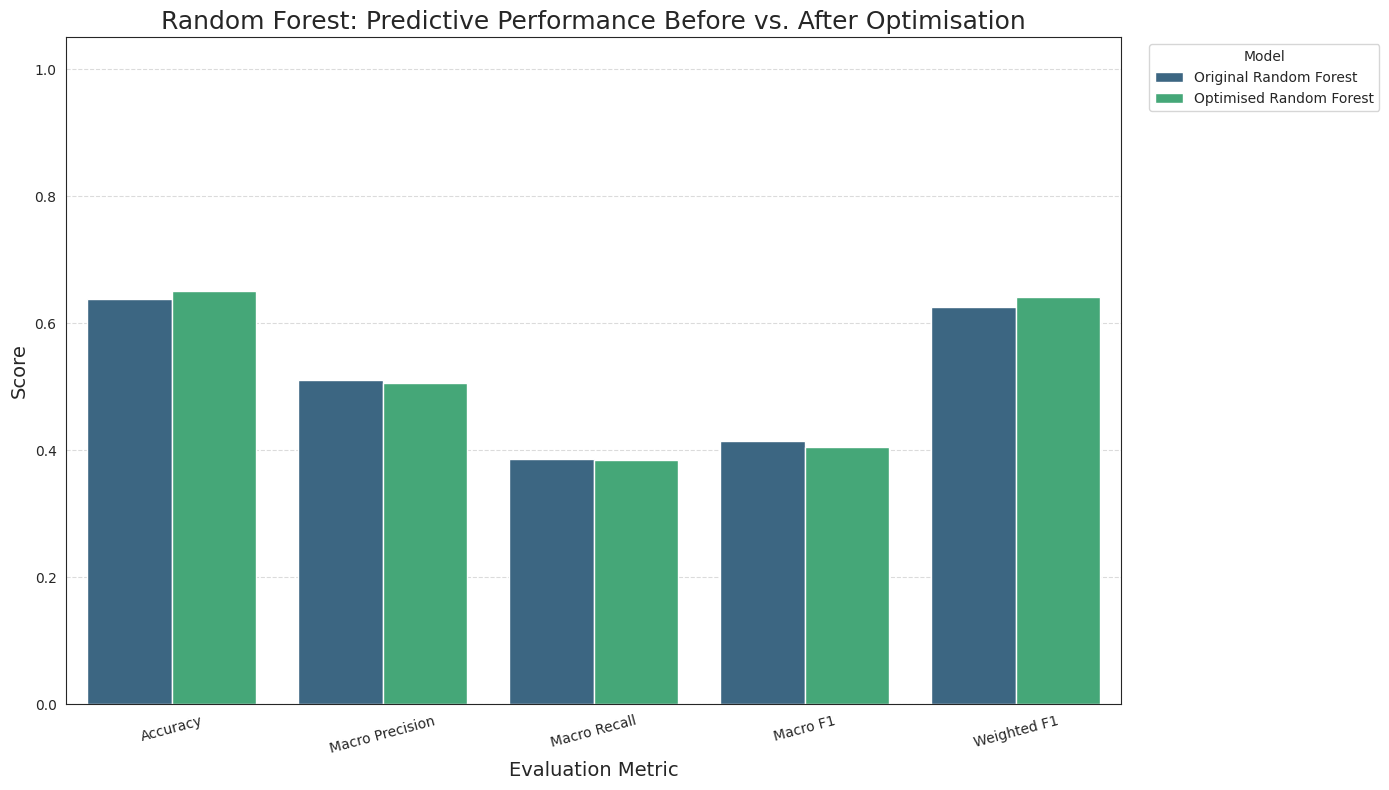

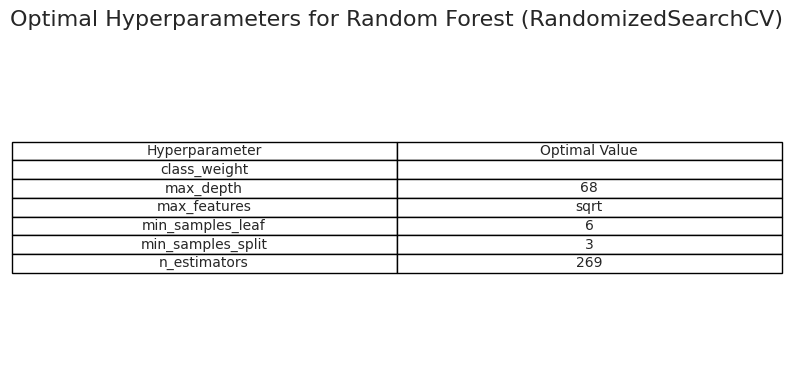

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Grouped bar chart comparing predictive metrics

# Prepare data for plotting predictive metrics
plot_metrics_df = comparison_optimisation_final_df.set_index('Model').loc[['Original Random Forest', 'Optimised Random Forest'], predictive_metrics].reset_index()
plot_metrics_df = plot_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8), dpi=100)
sns.barplot(x='Metric', y='Score', hue='Model', data=plot_metrics_df, palette='viridis')
plt.title('Random Forest: Predictive Performance Before vs. After Optimisation', fontsize=18)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_optimisation_predictive_metrics.png'), bbox_inches='tight')
plt.show()

print("\n")
# 2. A concise table summarising the best hyperparameters selected

# Convert best_params dictionary to a DataFrame for display
best_params_df = pd.DataFrame(best_params.items(), columns=['Hyperparameter', 'Optimal Value'])

plt.figure(figsize=(8, len(best_params_df) * 0.5 + 1), dpi=100)
# Hide axes
ax = plt.gca()
ax.axis('off')
ax.table(cellText=best_params_df.values, colLabels=best_params_df.columns, loc='center', cellLoc='center')
plt.title('Optimal Hyperparameters for Random Forest (RandomizedSearchCV)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_optimal_hyperparameters.png'), bbox_inches='tight')
plt.show()

### Part G – Engineering Interpretation

Hyperparameter optimisation produced modest improvements in predictive performance while increasing computational effort.

> **Key finding**
>
> Small performance gains may still be worthwhile if they improve clinically important predictions without substantially affecting deployment.

### Part H – Explainable AI Reflection

Optimisation changes how the Random Forest learns but does not change how it is interpreted.

Feature importance remains available, allowing the model to retain a useful level of transparency.

> **Explainable AI**
>
> Performance can improve without sacrificing the interpretability that supports clinician trust.

In [1]:
# Final checkpoint for Model Optimisation section
print("==================================================")
print("\n\u2713 MODEL OPTIMISATION COMPLETE")
print("Leading candidate optimised")
print("Performance compared")
print("Recommendation confirmed")
print("==================================================")


✓ MODEL OPTIMISATION COMPLETE
Leading candidate optimised
Performance compared
Recommendation confirmed


## 15. Final Engineering Recommendation

### Part A – Project Recap

This project developed and evaluated an explainable machine learning approach for Emergency Department triage.

| Stage | Outcome |
|:--|:--|
| Week 6 | Developed baseline models |
| Week 7 | Added engineered features and advanced models |
| Final stage | Benchmarked models and optimised the leading candidate |

The objective was to identify a model that balances predictive performance, interpretability and clinical practicality.

### Part B – Summary Table

In [69]:
import pandas as pd

# Create a DataFrame for the final summary table
final_summary_data = []

for model_name, row in benchmark_df.iterrows():
    # Qualitatively assess performance (based on Macro F1 and Accuracy)
    macro_f1 = row['Macro F1']
    accuracy = row['Accuracy']
    if macro_f1 > 0.5 and accuracy > 0.6:
        overall_performance = 'High'
    elif macro_f1 > 0.4 and accuracy > 0.5:
        overall_performance = 'Moderate'
    else:
        overall_performance = 'Low'

    # Qualitatively assess computational cost (based on Inference Time Per Prediction)
    inference_time = row['Inference Time Per Prediction (seconds)']
    # Adjusting thresholds for inference time per prediction to better differentiate models
    if inference_time < 5e-07:  # e.g., Dummy Classifier
        comp_cost = 'Very Low'
    elif inference_time < 5e-06: # e.g., Logistic Regression, Decision Tree, MLP
        comp_cost = 'Low'
    elif inference_time < 5e-05: # e.g., Gradient Boosting
        comp_cost = 'Moderate'
    else: # e.g., Random Forest
        comp_cost = 'High'

    # Clinical Suitability (qualitative judgment based on performance, interpretability, and speed)
    clinical_suitability = ""
    if model_name == 'Dummy Classifier':
        clinical_suitability = 'Reference point only; not suitable for clinical prediction.'
    elif model_name == 'Decision Tree':
        clinical_suitability = 'Good for illustrative purposes, but lacks robustness for critical decisions.'
    elif model_name == 'Logistic Regression':
        clinical_suitability = 'Solid statistical baseline, interpretable, but lower performance than ensembles.'
    elif model_name == 'Random Forest':
        clinical_suitability = 'Strong balance of performance and moderate interpretability, practical for deployment.'
    elif model_name == 'Gradient Boosting':
        clinical_suitability = 'High performance potential, but reduced interpretability makes it harder to trust.'
    elif model_name == 'Multi-Layer Perceptron':
        clinical_suitability = 'Highest performance potential but black-box nature limits trust and adoption.'

    final_summary_data.append({
        'Model': model_name,
        'Overall Performance': overall_performance,
        'Interpretability': row['Interpretability'],
        'Computational Cost (Inference)': comp_cost,
        'Clinical Suitability': clinical_suitability
    })

final_summary_df = pd.DataFrame(final_summary_data)

print("Final Engineering Recommendation Summary:")
display(final_summary_df)

Final Engineering Recommendation Summary:


,Model,Overall Performance,Interpretability,Computational Cost (Inference),Clinical Suitability
0,Dummy Classifier,Low,Very High (Random/Simple),Very Low,Reference point only; not suitable for clinica...
1,Logistic Regression,Moderate,High (Coefficients),Low,"Solid statistical baseline, interpretable, but..."
2,Decision Tree,Low,Very High (Flowchart),Low,"Good for illustrative purposes, but lacks robu..."
3,Random Forest,Moderate,Moderate (Feature Importance),High,Strong balance of performance and moderate int...
4,Gradient Boosting,Moderate,Low (Feature Importance),Moderate,"High performance potential, but reduced interp..."
5,Multi-Layer Perceptron,Moderate,Very Low (Black-Box),Low,Highest performance potential but black-box na...


### Part C – Recommendation

The optimised Random Forest was selected for continued development based on its balanced performance across multiple evaluation criteria.

| Strength | Contribution |
|:--|:--|
| Strong predictive performance | Reliable classification across ESI levels |
| Feature importance | Supports clinical interpretation |
| Efficient prediction | Suitable for real-time use |
| Balanced design | Practical for clinical deployment |

> **Summary**
>
> The model provides a strong balance between predictive performance, transparency and practical implementation.

### Part D – Explainable AI Reflection

Explainable AI aims to support clinical decisions through transparent and understandable predictions.

The Random Forest model contributes to this goal by highlighting the clinical features that most influenced its predictions.

> **Clinical value**
>
> Transparent models are more likely to support clinician confidence and responsible use in practice.

### Part E – Future Improvements

Future work could include:

– Improving probability calibration.

– Exploring patient-level explanations using SHAP.

– Validating the model with external datasets.

– Expanding evaluation using Caribbean clinical data.

– Testing the system in real clinical environments.

### Part F – Final Conclusion

This project demonstrated that selecting a clinical machine learning model requires balancing predictive performance with interpretability and practical deployment.

The optimised Random Forest achieved the strongest overall balance based on the current evaluation and provides a suitable foundation for future development of an explainable AI triage assistant.

In [70]:
# Final checkpoint for Week 7 notebook
print("==================================================")
print("\n\u2713 WEEK 7 NOTEBOOK COMPLETE")
print("Baseline models evaluated")
print("Advanced models benchmarked")
print("Leading model optimised")
print("Engineering recommendation produced")
print("Ready for report writing.")
print("==================================================")


✓ WEEK 7 NOTEBOOK COMPLETE
Baseline models evaluated
Advanced models benchmarked
Leading model optimised
Engineering recommendation produced
Ready for report writing.


## 16. Export Results and Reproducibility

### Part A – Introduction

Saving key outputs makes the project easier to reproduce, review and build upon.

The following files are exported for reporting, future development and model validation.

In [71]:
# Create the 'docs' folder if it does not already exist.
# This is where we will save our final tables and summaries.
docs_folder = 'docs'
if not os.path.exists(docs_folder):
    os.makedirs(docs_folder)
    print(f"Created folder: {docs_folder}/")
else:
    print(f"Folder already exists: {docs_folder}/")

Created folder: docs/


### Part B – Export Benchmark Tables

The benchmark tables are exported to preserve the final comparison of model performance and engineering trade-offs.

In [72]:
# Export the comprehensive model benchmark table
if 'benchmark_df' in globals() and isinstance(benchmark_df, pd.DataFrame):
    benchmark_output_path = os.path.join(docs_folder, 'week7_model_benchmark.csv')
    benchmark_df.to_csv(benchmark_output_path, index=True)
    print(f"\u2713 Benchmark comparison table saved to: {benchmark_output_path}")
else:
    print("Benchmark DataFrame (benchmark_df) not found or not a DataFrame. Skipping export.")

# Export the optimised model comparison table
if 'comparison_optimisation_final_df' in globals() and isinstance(comparison_optimisation_final_df, pd.DataFrame):
    optimised_comparison_output_path = os.path.join(docs_folder, 'week7_optimised_model_comparison.csv')
    comparison_optimisation_final_df.to_csv(optimised_comparison_output_path, index=False)
    print(f"\u2713 Optimised model comparison table saved to: {optimised_comparison_output_path}")
else:
    print("Optimisation comparison DataFrame (comparison_optimisation_final_df) not found or not a DataFrame. Skipping export.")

✓ Benchmark comparison table saved to: docs/week7_model_benchmark.csv
✓ Optimised model comparison table saved to: docs/week7_optimised_model_comparison.csv


### Part C – Export Feature Importance

Feature importance scores are exported to support model interpretation and future clinical review.

In [73]:
# Export Random Forest feature importance
if 'rf_optimised' in globals() and hasattr(rf_optimised, 'feature_importances_'):
    rf_feature_importances = pd.Series(rf_optimised.feature_importances_, index=X_train_fe.columns)
    rf_feature_importances_path = os.path.join(docs_folder, 'random_forest_feature_importance.csv')
    rf_feature_importances.sort_values(ascending=False).to_csv(rf_feature_importances_path, header=['Importance'], index_label='Feature')
    print(f"\u2713 Random Forest feature importance saved to: {rf_feature_importances_path}")
else:
    print("Optimised Random Forest model or its feature importances not found. Skipping export.")

# Export Gradient Boosting feature importance
if 'gb' in globals() and hasattr(gb, 'feature_importances_'):
    gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train_fe.columns)
    gb_feature_importances_path = os.path.join(docs_folder, 'gradient_boosting_feature_importance.csv')
    gb_feature_importances.sort_values(ascending=False).to_csv(gb_feature_importances_path, header=['Importance'], index_label='Feature')
    print(f"\u2713 Gradient Boosting feature importance saved to: {gb_feature_importances_path}")
else:
    print("Gradient Boosting model or its feature importances not found. Skipping export.")

✓ Random Forest feature importance saved to: docs/random_forest_feature_importance.csv
✓ Gradient Boosting feature importance saved to: docs/gradient_boosting_feature_importance.csv


### Part D – Save Model Predictions

The final model predictions are saved to support future validation, error analysis and model refinement.

In [74]:
# Save predictions for the final recommended model (Optimised Random Forest)
if 'rf_optimised_preds' in globals() and 'y_test' in globals():
    predictions_df = pd.DataFrame({
        'Actual ESI Level': y_test,
        'Predicted ESI Level': rf_optimised_preds
    })
    predictions_output_path = os.path.join(docs_folder, 'final_model_predictions.csv')
    predictions_df.to_csv(predictions_output_path, index=False)
    print(f"\u2713 Final model predictions saved to: {predictions_output_path}")
else:
    print("Optimised Random Forest predictions or actual ESI levels not found. Skipping export.")

✓ Final model predictions saved to: docs/final_model_predictions.csv


### Part E – Reproducibility Summary

| Component | Setting |
|:--|:--|
| Dataset | `yaleemmlc_admissionprediction_triage.csv` |
| Random seed | `42` |
| Train/test split | 80/20 stratified |
| Clinical features | 207 original features |
| Engineered features | 4 additional features |
| Baseline models | Dummy Classifier, Logistic Regression, Decision Tree |
| Advanced models | Random Forest, Gradient Boosting, MLP |
| Selected model | Optimised Random Forest |
| Optimisation | RandomizedSearchCV (30 iterations, 3-fold CV) |
| Main libraries | pandas, numpy, matplotlib, scikit-learn, joblib |

> **Purpose**
>
> These settings summarise the experimental configuration and support reproducibility.

### Part F – Project Reflection

This project demonstrated the process of developing and evaluating an explainable machine learning approach for emergency department triage.

The comparison of multiple models showed that selecting a clinical AI system requires balancing predictive performance, interpretability and practical deployment rather than focusing on accuracy alone.

> **Final reflection**
>
> The optimised Random Forest provided the strongest overall balance and represents a suitable foundation for future development of an explainable clinical decision-support system.

In [75]:
# Final checkpoint for Week 7 notebook
print("==================================================")
print("\n\u2713 WEEK 7 COMPLETE")
print("All notebook sections completed successfully.")
print("Results exported.")
print("==================================================")


✓ WEEK 7 COMPLETE
All notebook sections completed successfully.
Results exported.
